연령 : age

성별 : sex 
(1: 남자, 2:여자)

흡연 여부 : BS3_1
(1: 매일피움, 2: 가끔, 3: 과거에는 피웠으나, 현재 피우지 않음, 4: 비해당)

음주 빈도 : BD1_11 
(0: 전혀 마신적이 없음, 1: 최근 1년간 전혀 마시지 않았다, 2: 월1회미만, 3: 월1회정도, 4: 월2~4회, 5: 주2~3회정도, 6: 주4회이상)

칫솔질 여부 : BMI_1 ~ 8 
(0: 아니오, 1: 예)

구강용품 : BM2_SUM
(0:아니오, 1: 예)

구강검진(정기검진) : OR1_2
(0: 아니오, 1: 예)

당뇨여부 : DE1_dg 
(0: 없음, 1: 있음)

치주질환여부 : NO_CPI_34 
(0: 아니오, 1: 예)

우울증 여부 : DF2_pr
(0: 없음, 1: 있음)

평소 스트레스 인지 정도 : BP1 
(1. 대단히 많이 느낀다, 2. 많이 느끼는 편이다, 3. 조금 느끼는 편이다, 4. 거의 느끼지 않는다.)

비만 여부 : HE_obe 
(1. 저체중, 2. 정상, 3. 비만)

주중 하루 평균 수면시간 : Total_slp_wk 
(()분, 8888. 비해당(소아), 9999. 모름, 무응답) ** 8888, 9999값 삭제

주말 하루 평균 수면시간 : Total_slp_wd
(()분, 8888. 비해당(소아), 9999. 모름, 무응답) ** 8888, 9999값 삭제

소득 5분위수(개인) : ncm5
1. 하, 2. 중하, 3. 중, 4. 중상, 5. 상

교정치료 경험 유무 : O_ortho
0. 아니오, 1.예

예방치료 경험 유무(실란트, 불소도포, 단순 스케일링 등) : MO4_17
0. 아니오, 1.예

임플란트 존재유무 : O_IMP_SUM
0. 존재안함, 1. 1개 이상 존재함

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [추가 작업: 학습 데이터 내 0번 클래스 4배로 늘리기] ---
train_df = pd.concat([X_train, y_train], axis=1)
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

# 0번 데이터를 4배로 복제 (총 4배)
df_class_0_oversampled = pd.concat([df_class_0] * 400, axis=0)
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

# 데이터 셔플
train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']
# ---------------------------------------------------------

# 4. 모델 생성 및 학습 (증폭된 데이터 사용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력 (기본 predict 버전)
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"원본 학습 데이터 0번 클래스 수: {len(df_class_0)}")
print(f"증폭 후 학습 데이터 0번 클래스 수: {len(df_class_0_oversampled)}")
print("-" * 50)
print(f"\n[기본 임계값(0.5) 결과 보고서]")
print(classification_report(y_test, final_pred))

# 6. 결과 출력 (임계값 조정 버전)
# 단순히 predict 하는 대신 모델이 계산한 환자일 확률(probability)을 가져옵니다.
final_proba = final_model.predict_proba(X_test)[:, 1]

# 임계값을 0.5에서 0.65로 상향 (환자라고 확신하는 기준을 높임)
custom_threshold = 0.65
final_pred_custom = (final_proba >= custom_threshold).astype(int)

print(f"\n[임계값 {custom_threshold} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred_custom))


--------------------------------------------------
적용된 Random State: 152785
원본 학습 데이터 0번 클래스 수: 6208
증폭 후 학습 데이터 0번 클래스 수: 2483200
--------------------------------------------------

[기본 임계값(0.5) 결과 보고서]
              precision    recall  f1-score   support

         0.0       0.84      0.58      0.69      2071
         1.0       0.44      0.75      0.56       929

    accuracy                           0.63      3000
   macro avg       0.64      0.66      0.62      3000
weighted avg       0.72      0.63      0.65      3000


[임계값 0.65 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.74      0.87      0.80      2071
         1.0       0.53      0.33      0.41       929

    accuracy                           0.70      3000
   macro avg       0.64      0.60      0.61      3000
weighted avg       0.68      0.70      0.68      3000



In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

# 요청하신 특정 random_state 값
target_rs = 152785

# 3. 데이터 분할 및 모델 학습
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# 모델 생성 및 학습 (random_state 적용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train, y_train)

# 4. 결과 출력
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print("-" * 50)
print(f"\n[최적 Random State {target_rs} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

--------------------------------------------------
적용된 Random State: 152785
--------------------------------------------------

[최적 Random State 152785 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.84      0.58      0.69      2071
         1.0       0.44      0.75      0.56       929

    accuracy                           0.63      3000
   macro avg       0.64      0.66      0.62      3000
weighted avg       0.72      0.63      0.65      3000



In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils import resample  # SMOTE 대신 사용할 라이브러리

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 데이터 분할
target_rs = 152785
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# 3. 데이터 수동 오버샘플링 (SMOTE 대체)
# 학습 데이터 결합
train_data = pd.concat([X_train, y_train], axis=1)

# 클래스 분리
df_majority = train_data[train_data.NO_CPI_34 == 0]
df_minority = train_data[train_data.NO_CPI_34 == 1]

# 소수 클래스(1)를 다수 클래스(0)의 개수만큼 복제하여 성능 극대화
df_minority_upsampled = resample(df_minority, 
                                 replace=True,     # 샘플 복제 허용
                                 n_samples=len(df_majority), 
                                 random_state=target_rs)

# 다시 결합
df_upsampled = pd.concat([df_majority, df_minority_upsampled])
X_train_res = df_upsampled.drop('NO_CPI_34', axis=1)
y_train_res = df_upsampled['NO_CPI_34']

# 4. 하이퍼파라미터 설정 (규제 완전 해제)
best_params = {
    'criterion': 'entropy',
    'max_depth': None,           # 나무가 끝까지 자라도록 제한 해제
    'min_samples_leaf': 1,       # 단일 데이터까지 추적
    'min_samples_split': 2,
    'class_weight': None         # 이미 오버샘플링을 했으므로 None
}

# 5. 모델 생성 및 학습
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_res, y_train_res)

# 6. 결과 출력
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"오버샘플링 후 학습 데이터 크기: {len(X_train_res)}")
print("-" * 50)
print(f"\n[성능 극대화 결과 보고서]")
print(classification_report(y_test, final_pred))

--------------------------------------------------
적용된 Random State: 152785
오버샘플링 후 학습 데이터 크기: 12416
--------------------------------------------------

[성능 극대화 결과 보고서]
              precision    recall  f1-score   support

         0.0       0.74      0.75      0.74      2071
         1.0       0.42      0.40      0.41       929

    accuracy                           0.64      3000
   macro avg       0.58      0.58      0.58      3000
weighted avg       0.64      0.64      0.64      3000



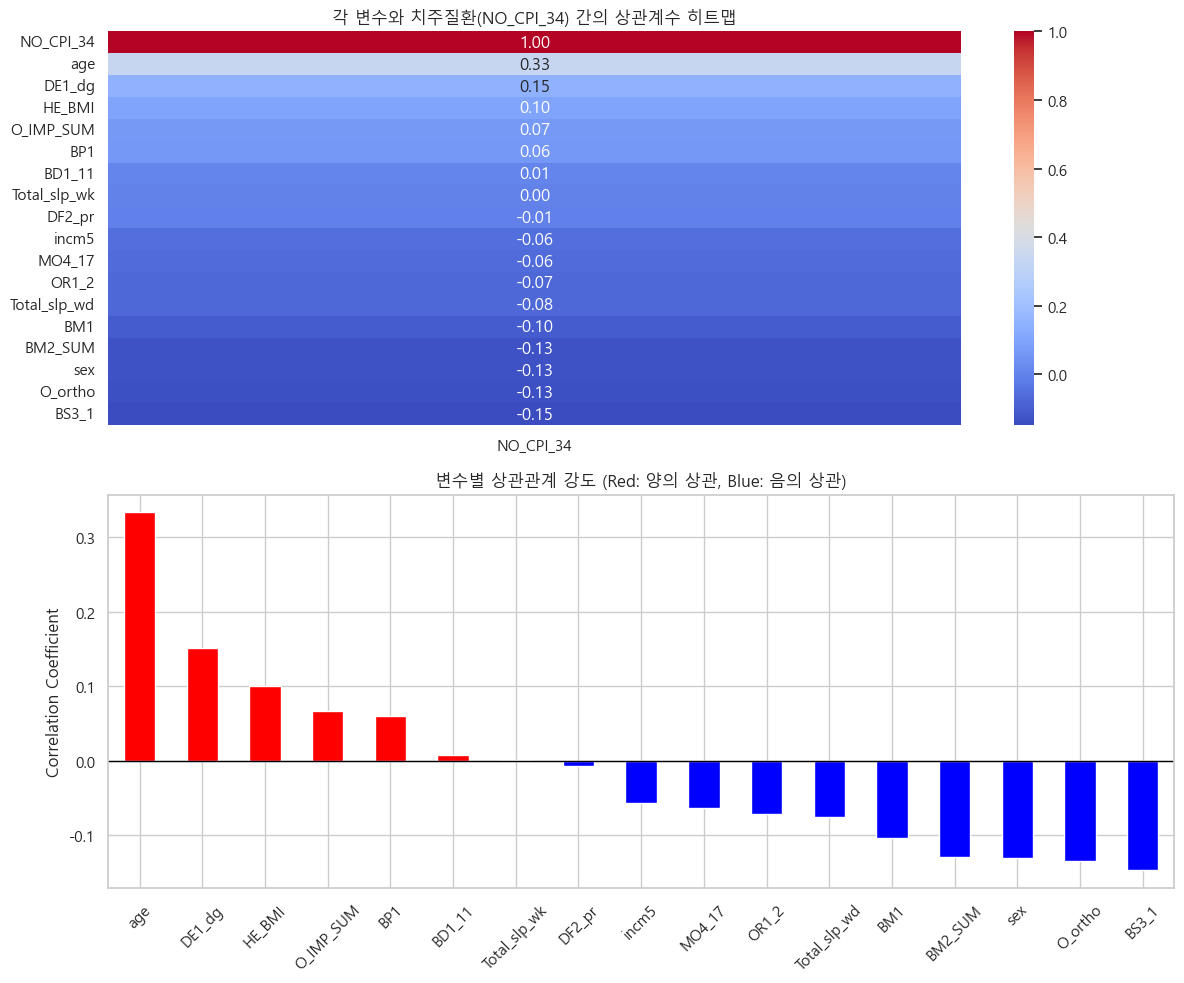

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Colab 또는 Windows 환경에 맞춰 설정이 필요할 수 있습니다)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 기본 전처리 (앞선 코드와 동일)
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 2. 상관계수 계산
# 모든 변수와 NO_CPI_34 간의 상관관계를 계산합니다.
correlation_matrix = df.corr()
target_corr = correlation_matrix['NO_CPI_34'].sort_values(ascending=False)

# 3. 시각화 (2가지 방식)

# 그래프 크기 설정
plt.figure(figsize=(12, 10))

# [방법 1: 전체 히트맵]
plt.subplot(2, 1, 1)
sns.heatmap(correlation_matrix[['NO_CPI_34']].sort_values(by='NO_CPI_34', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('각 변수와 치주질환(NO_CPI_34) 간의 상관계수 히트맵')

# [방법 2: 타겟 변수와의 상관관계 막대 그래프]
plt.subplot(2, 1, 2)
# 자기 자신(NO_CPI_34) 제외하고 시각화
target_corr_filtered = target_corr.drop('NO_CPI_34')
colors = ['red' if x > 0 else 'blue' for x in target_corr_filtered]
target_corr_filtered.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('변수별 상관관계 강도 (Red: 양의 상관, Blue: 음의 상관)')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

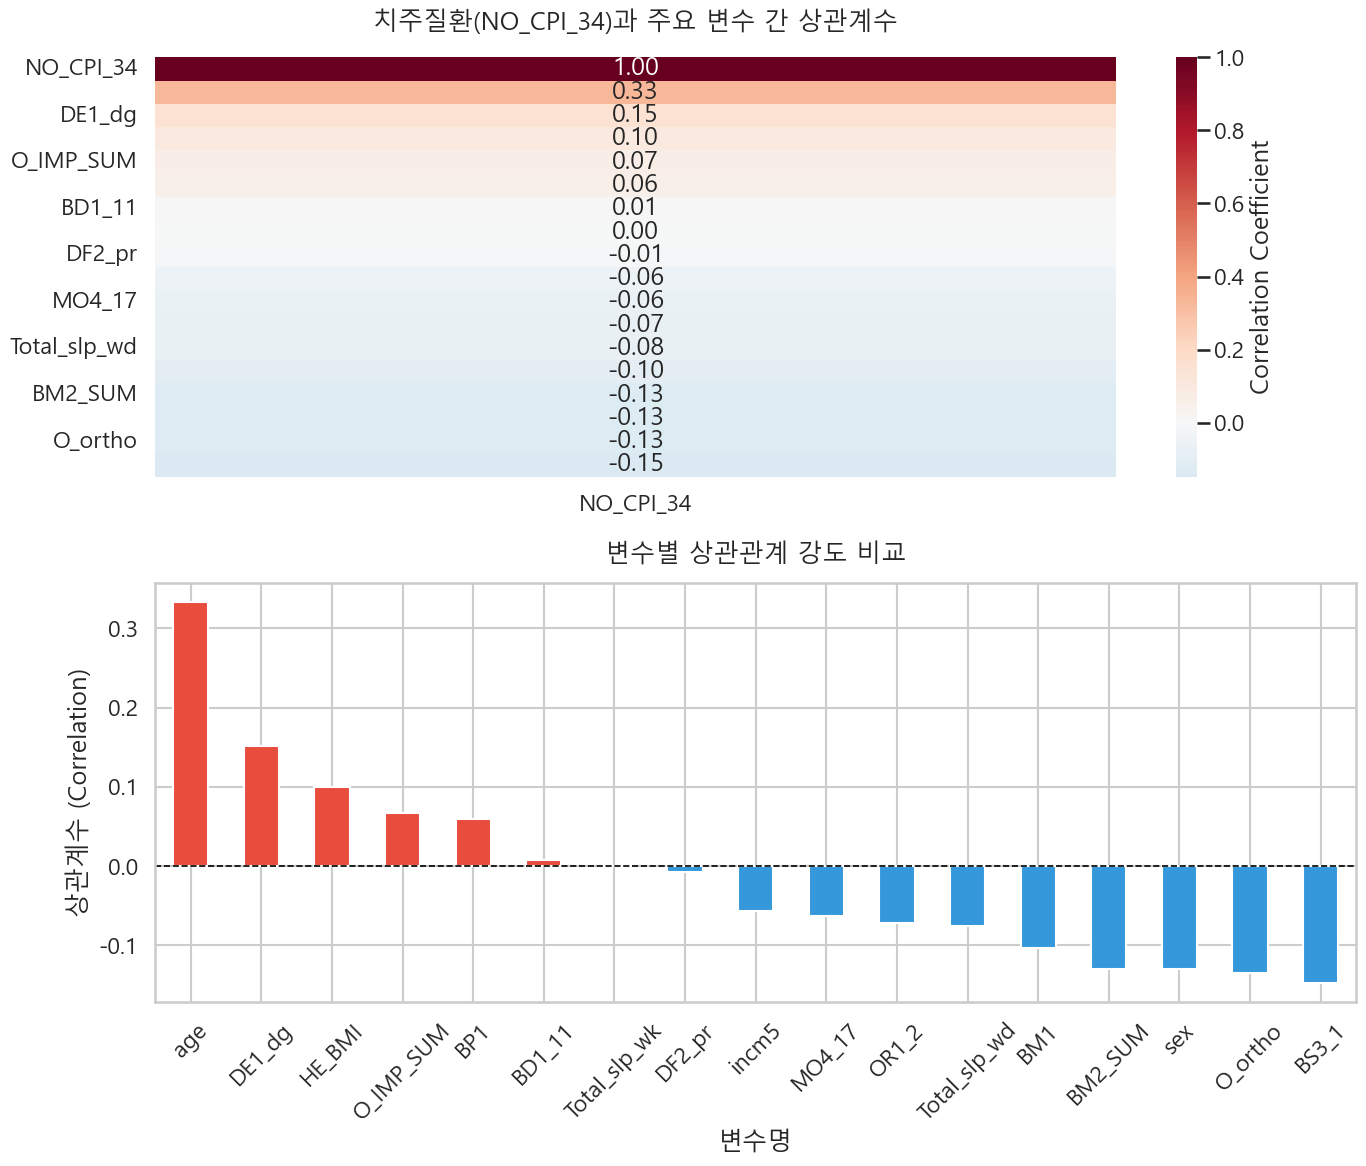

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows: Malgun Gothic, Mac: AppleGothic
plt.rcParams['axes.unicode_minus'] = False
sns.set_context("talk") # 글자 크기 최적화

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# [중요] 상관계수 계산을 위해 범주형 변수를 수치형으로 변환 (Label Encoding)
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 3. 상관계수 계산
correlation_matrix = df_encoded.corr()
# 타겟 변수(NO_CPI_34)와 다른 변수들 간의 상관관계 추출 및 정렬
target_corr = correlation_matrix['NO_CPI_34'].sort_values(ascending=False)

# 4. 시각화
plt.figure(figsize=(14, 12))

# [상단: 히트맵] - 타겟 변수와의 관계만 집중
plt.subplot(2, 1, 1)
sns.heatmap(correlation_matrix[['NO_CPI_34']].sort_values(by='NO_CPI_34', ascending=False), 
            annot=True, cmap='RdBu_r', center=0, fmt=".2f", cbar_kws={'label': 'Correlation Coefficient'})
plt.title('치주질환(NO_CPI_34)과 주요 변수 간 상관계수', pad=20)

# [하단: 막대 그래프] - 직관적인 크기 비교
plt.subplot(2, 1, 2)
# 자기 자신(NO_CPI_34) 제외
target_corr_filtered = target_corr.drop('NO_CPI_34')
# 양수(빨강), 음수(파랑) 색상 지정
colors = sns.diverging_palette(240, 10, n=len(target_corr_filtered))
target_corr_filtered.plot(kind='bar', color=['#e74c3c' if x > 0 else '#3498db' for x in target_corr_filtered])

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.title('변수별 상관관계 강도 비교', pad=15)
plt.ylabel('상관계수 (Correlation)')
plt.xlabel('변수명')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

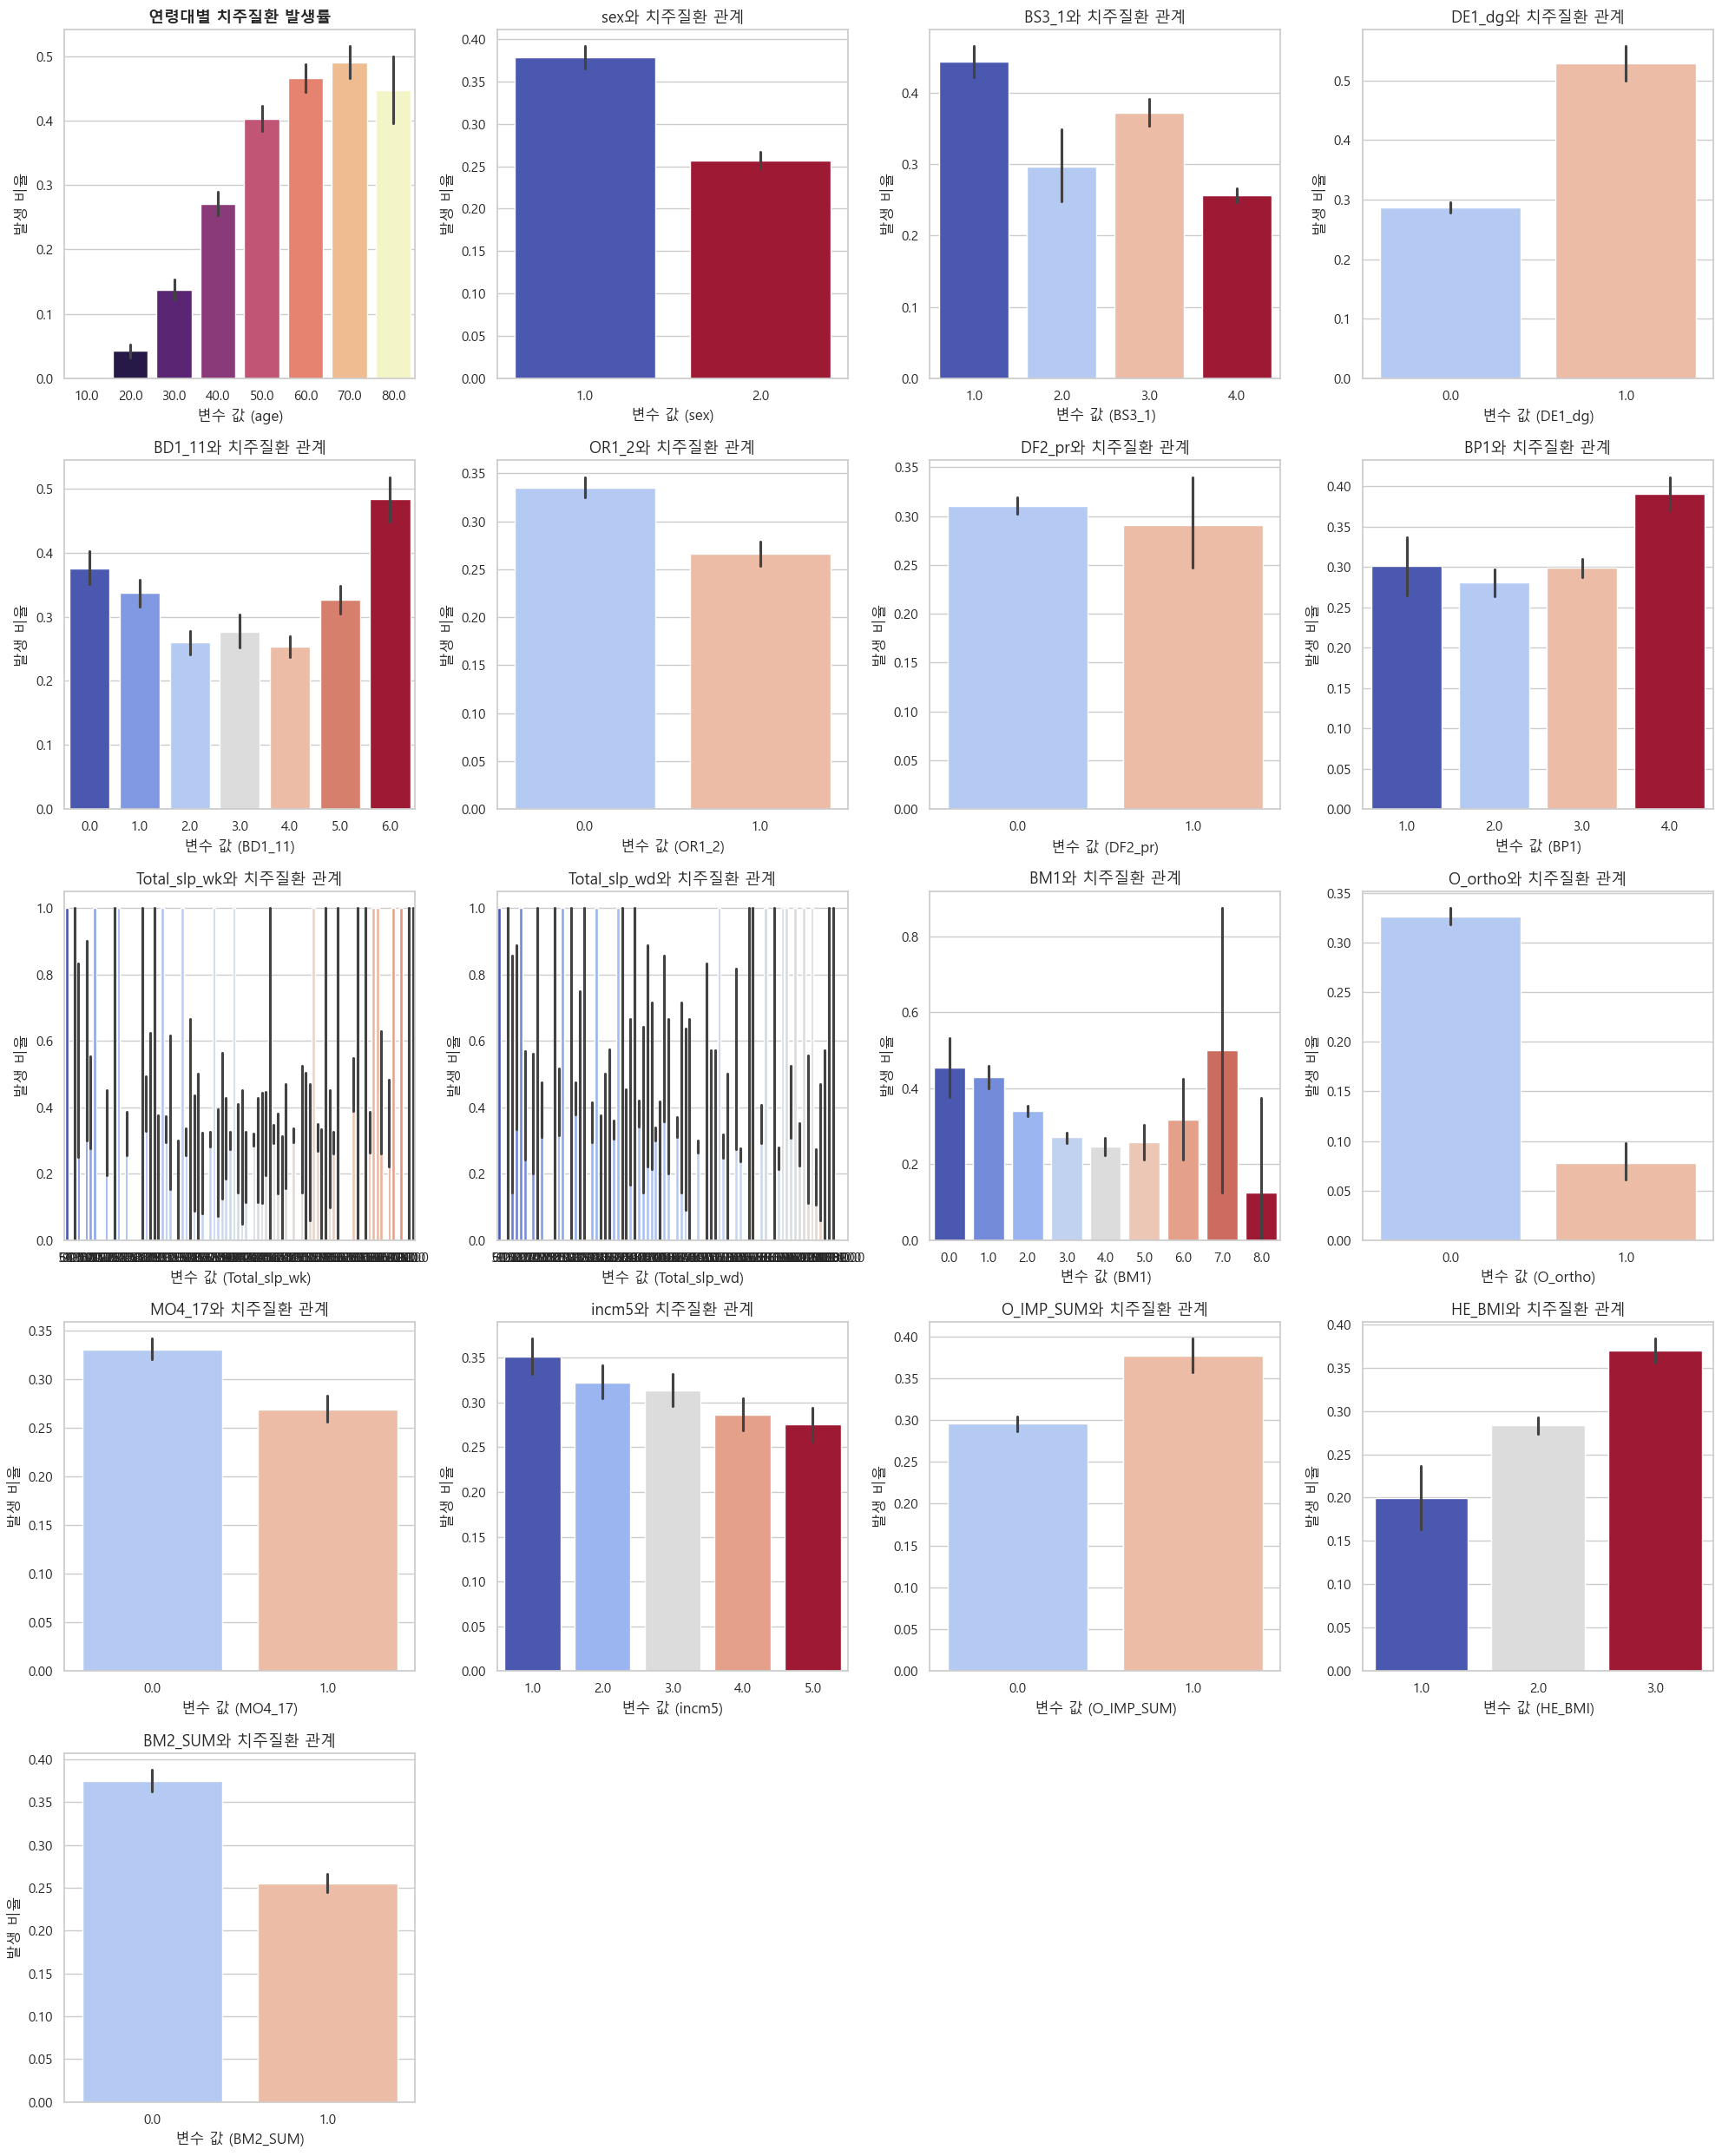

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 및 결측치 제거
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 분석 대상 컬럼 자동 선별
# 타겟 변수와 시각화에서 제외할 임시 컬럼(age_group 등) 정의
target = 'NO_CPI_34'
# 데이터프레임에 실제로 존재하는 컬럼만 추출 (숫자형 데이터 위주)
all_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target in all_cols:
    all_cols.remove(target)

# 4. 서브플롯 동적 생성
# 컬럼 개수에 맞춰 행과 열 계산 (한 줄에 4개씩 배치)
n_cols = 4
n_rows = (len(all_cols) + n_cols) // n_cols # 'age' 포함 전체 변수 개수 기준

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

# 5. 모든 컬럼에 대해 순회하며 그래프 작성
for i, col in enumerate(all_cols):
    if col == 'age':
        # 연령은 10세 단위로 그룹화하여 시각화
        df['age_group'] = (df['age'] // 10) * 10
        sns.barplot(x='age_group', y=target, data=df, ax=axes[i], palette='magma', hue='age_group', legend=False)
        axes[i].set_title('연령대별 치주질환 발생률', fontsize=13, fontweight='bold')
    else:
        # 나머지 모든 변수와 타겟의 상관관계(발생률) 시각화
        # palette 설정 시 hue를 자기 자신으로 설정하여 경고 메시지 방지
        sns.barplot(x=col, y=target, data=df, ax=axes[i], palette='coolwarm', hue=col, legend=False)
        axes[i].set_title(f'{col}와 치주질환 관계', fontsize=13)
    
    axes[i].set_ylabel('발생 비율')
    axes[i].set_xlabel(f'변수 값 ({col})')

# 남는 빈 서브플롯 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

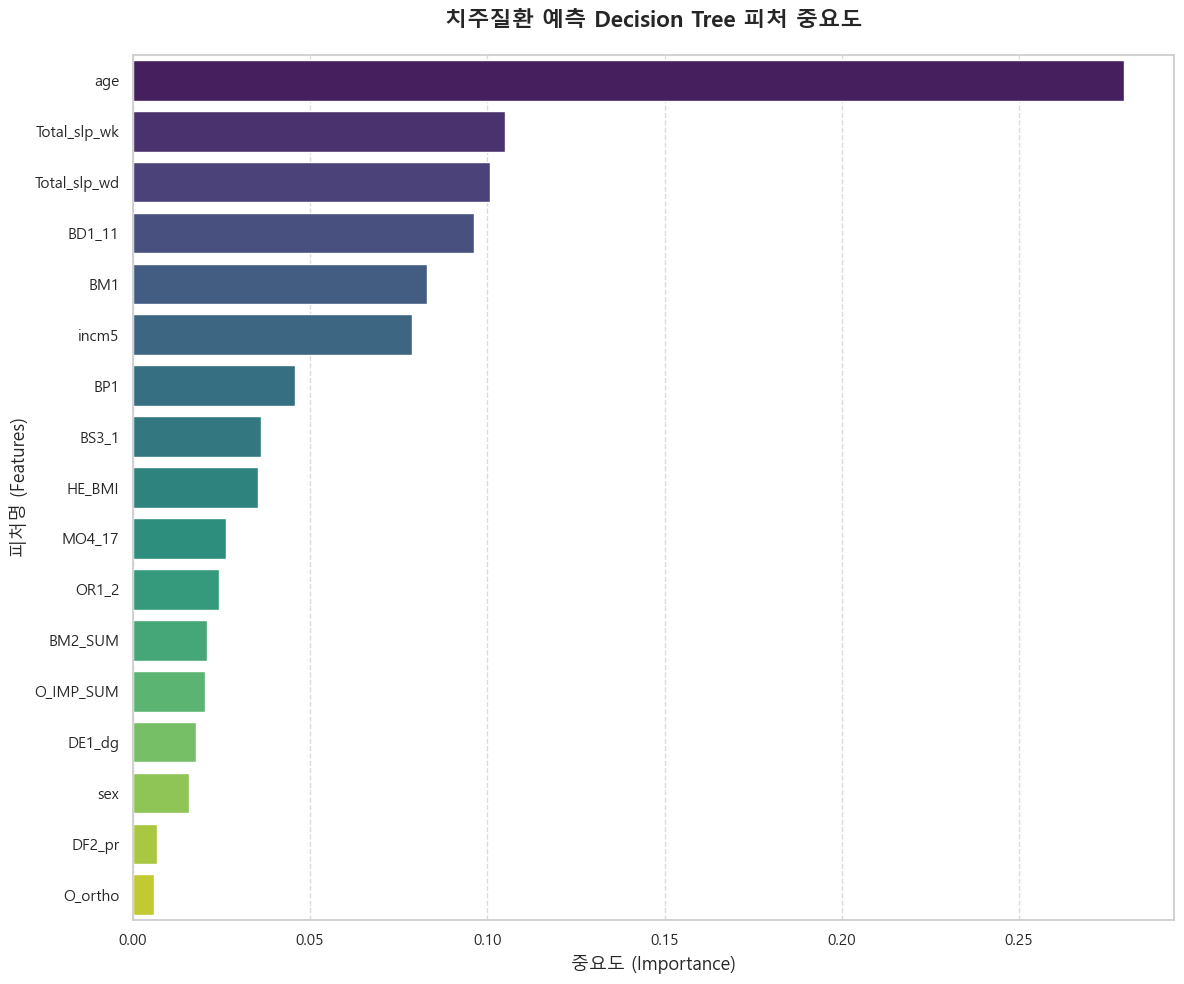

--------------------------------------------------
[상위 5개 주요 피처 수치]
     Feature  Importance
         age    0.279700
Total_slp_wk    0.105089
Total_slp_wd    0.100818
      BD1_11    0.096282
         BM1    0.083132
--------------------------------------------------


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (필요시 활성화)
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['axes.unicode_minus'] = False

# 2. 피처 중요도 추출
# 모델 학습이 완료된 후 실행해야 합니다.
importances = final_model.feature_importances_
feature_names = X_train.columns

# 3. 중요도를 기준으로 내림차순 정렬
# 데이터프레임으로 만들어 정렬하면 시각화가 쉽습니다.
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. 시각화 (막대 그래프)
plt.figure(figsize=(12, 10))
# palette를 'viridis'나 'magma'로 설정하여 중요도가 높을수록 진하게 표현
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)

# 그래프 레이아웃 다듬기
plt.title('치주질환 예측 Decision Tree 피처 중요도', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('중요도 (Importance)', fontsize=13)
plt.ylabel('피처명 (Features)', fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.7) # x축에만 그리드 추가

plt.tight_layout()
plt.show()

# 5. 수치로 확인 (상위 5개)
print("-" * 50)
print("[상위 5개 주요 피처 수치]")
print(feature_imp_df.head(5).to_string(index=False))
print("-" * 50)

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils import resample  # SMOTE 대신 사용할 라이브러리

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 데이터 분할
target_rs = 152785
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# 3. 데이터 수동 오버샘플링 (SMOTE 대체)
# 학습 데이터 결합
train_data = pd.concat([X_train, y_train], axis=1)

# 클래스 분리
df_majority = train_data[train_data.NO_CPI_34 == 0]
df_minority = train_data[train_data.NO_CPI_34 == 1]

# 소수 클래스(1)를 다수 클래스(0)의 개수만큼 복제하여 성능 극대화
df_minority_upsampled = resample(df_minority, 
                                 replace=True,     # 샘플 복제 허용
                                 n_samples=len(df_majority), 
                                 random_state=target_rs)

# 다시 결합
df_upsampled = pd.concat([df_majority, df_minority_upsampled])
X_train_res = df_upsampled.drop('NO_CPI_34', axis=1)
y_train_res = df_upsampled['NO_CPI_34']

# 4. 하이퍼파라미터 설정 (규제 완전 해제)
best_params = {
    'criterion': 'entropy',
    'max_depth': None,           # 나무가 끝까지 자라도록 제한 해제
    'min_samples_leaf': 1,       # 단일 데이터까지 추적
    'min_samples_split': 2,
    'class_weight': None         # 이미 오버샘플링을 했으므로 None
}

# 5. 모델 생성 및 학습
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_res, y_train_res)

# 6. 결과 출력
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"오버샘플링 후 학습 데이터 크기: {len(X_train_res)}")
print("-" * 50)
print(f"\n[성능 극대화 결과 보고서]")
print(classification_report(y_test, final_pred))

Task was destroyed but it is pending!
task: <Task pending name='Task-319' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Project\Project_source\AI01\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-320' coro=<Kernel.shell_main() running at C:\Project\Project_source\AI01\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Project\Project_source\AI01\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Project\Project_source\AI01\.venv\Lib\site-packages\pandas\core\internals\blocks.py:2255: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return klass(values, ndim=2, placement=placement, refs=refs)
Task was destroyed but it is pending!
task: <Task pending name='Task-320' coro=<Kernel.shell_main() running at C:\Project\Project_source\AI01\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


--------------------------------------------------
적용된 Random State: 152785
오버샘플링 후 학습 데이터 크기: 12416
--------------------------------------------------

[성능 극대화 결과 보고서]
              precision    recall  f1-score   support

         0.0       0.74      0.75      0.74      2071
         1.0       0.42      0.40      0.41       929

    accuracy                           0.64      3000
   macro avg       0.58      0.58      0.58      3000
weighted avg       0.64      0.64      0.64      3000



In [21]:
from sklearn.metrics import accuracy_score

# 정확도 계산
accuracy = accuracy_score(y_test, final_pred)

print(f"최종 모델 정확도: {accuracy:.4f}")
print(f"최종 모델 정확도(percentage): {accuracy * 100:.2f}%")

최종 모델 정확도: 0.6430
최종 모델 정확도(percentage): 64.30%


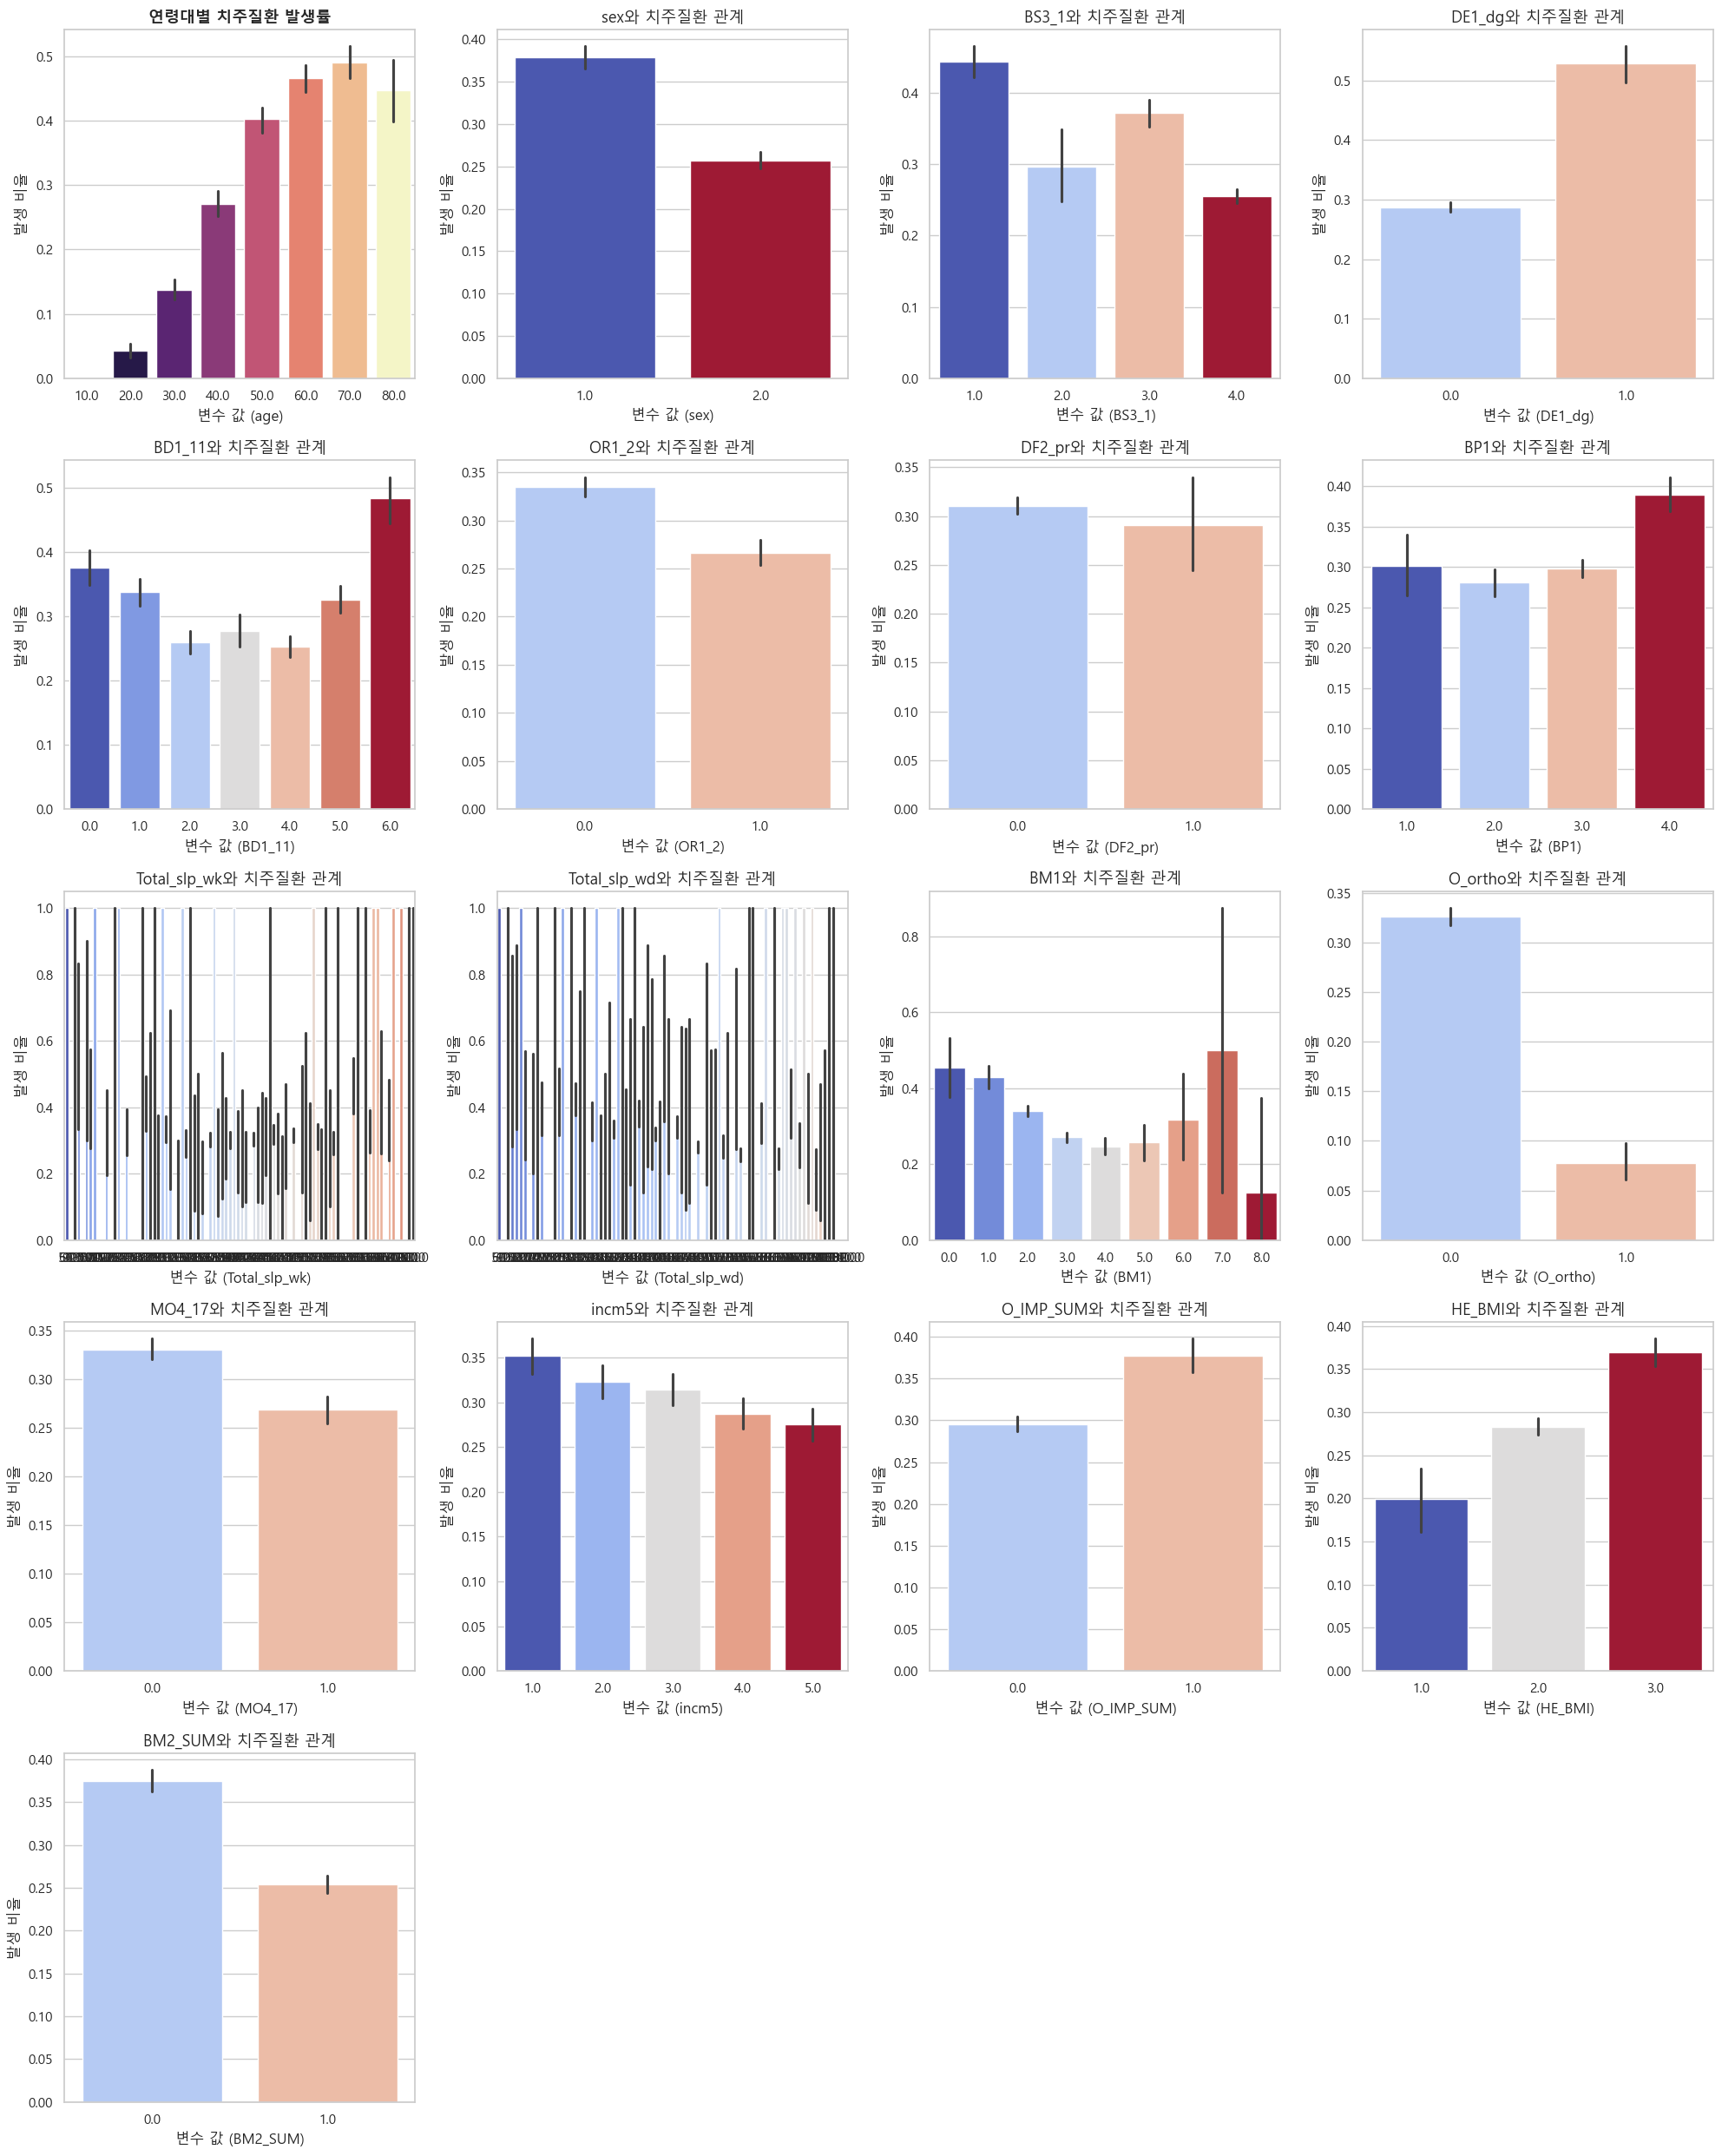

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 및 결측치 제거
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 분석 대상 컬럼 자동 선별
# 타겟 변수와 시각화에서 제외할 임시 컬럼(age_group 등) 정의
target = 'NO_CPI_34'
# 데이터프레임에 실제로 존재하는 컬럼만 추출 (숫자형 데이터 위주)
all_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target in all_cols:
    all_cols.remove(target)

# 4. 서브플롯 동적 생성
# 컬럼 개수에 맞춰 행과 열 계산 (한 줄에 4개씩 배치)
n_cols = 4
n_rows = (len(all_cols) + n_cols) // n_cols # 'age' 포함 전체 변수 개수 기준

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

# 5. 모든 컬럼에 대해 순회하며 그래프 작성
for i, col in enumerate(all_cols):
    if col == 'age':
        # 연령은 10세 단위로 그룹화하여 시각화
        df['age_group'] = (df['age'] // 10) * 10
        sns.barplot(x='age_group', y=target, data=df, ax=axes[i], palette='magma', hue='age_group', legend=False)
        axes[i].set_title('연령대별 치주질환 발생률', fontsize=13, fontweight='bold')
    else:
        # 나머지 모든 변수와 타겟의 상관관계(발생률) 시각화
        # palette 설정 시 hue를 자기 자신으로 설정하여 경고 메시지 방지
        sns.barplot(x=col, y=target, data=df, ax=axes[i], palette='coolwarm', hue=col, legend=False)
        axes[i].set_title(f'{col}와 치주질환 관계', fontsize=13)
    
    axes[i].set_ylabel('발생 비율')
    axes[i].set_xlabel(f'변수 값 ({col})')

# 남는 빈 서브플롯 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

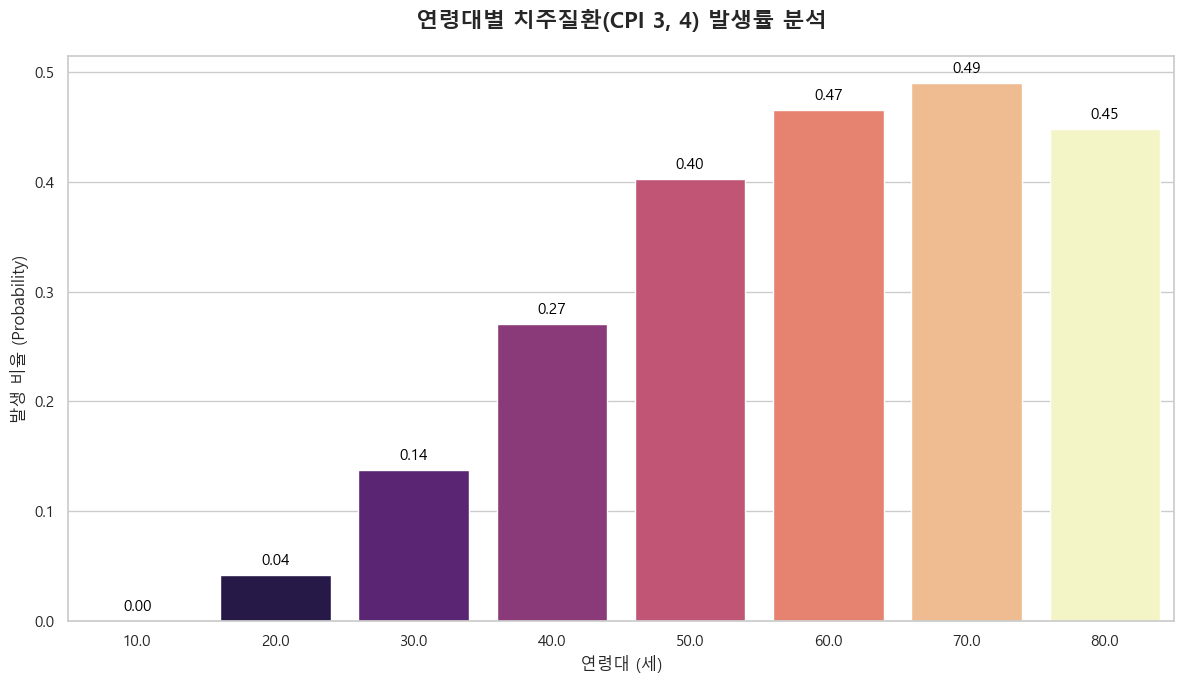

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (Windows 기준 'Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 및 결측치 제거
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 연령대 그룹화 및 타겟 변수 설정
target = 'NO_CPI_34'
df['age_group'] = (df['age'] // 10) * 10

# 4. 단일 그래프 시각화 (연령대별 발생률)
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 막대 그래프 생성
ax = sns.barplot(
    x='age_group', 
    y=target, 
    data=df, 
    palette='magma', 
    hue='age_group', 
    legend=False,
    errorbar=None # 오차 막대 제거 시 더 깔끔함
)

# 제목 및 라벨 설정
plt.title('연령대별 치주질환(CPI 3, 4) 발생률 분석', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('연령대 (세)', fontsize=12)
plt.ylabel('발생 비율 (Probability)', fontsize=12)

# 각 막대 위에 수치 표시 (선택 사항)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.tight_layout()
plt.show()

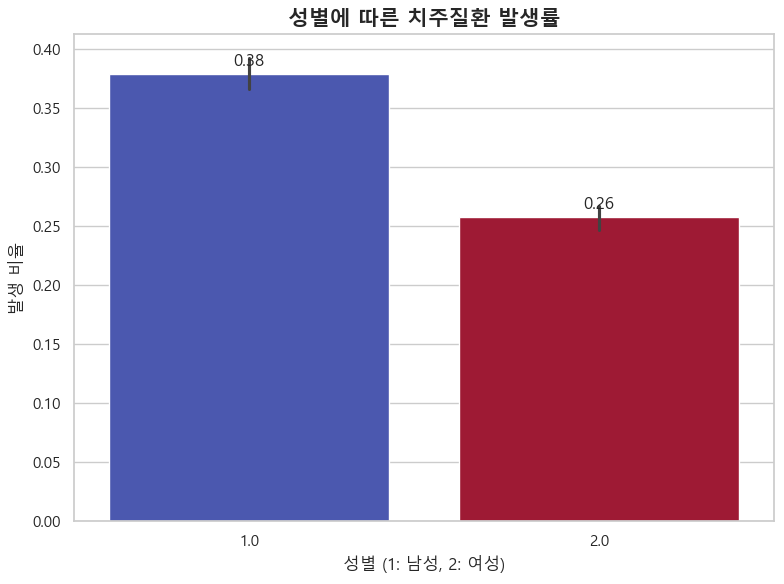

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 및 결측치 제거
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 성별(sex)과 치주질환(NO_CPI_34) 관계 시각화
plt.figure(figsize=(8, 6))

target = 'NO_CPI_34'
col = 'sex'

# 그래프 생성
ax = sns.barplot(x=col, y=target, data=df, palette='coolwarm', hue=col, legend=False)

# 제목 및 라벨 설정
plt.title('성별에 따른 치주질환 발생률', fontsize=15, fontweight='bold')
plt.ylabel('발생 비율')
plt.xlabel('성별 (1: 남성, 2: 여성)')

# 막대 위에 수치 표시 (선택 사항)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

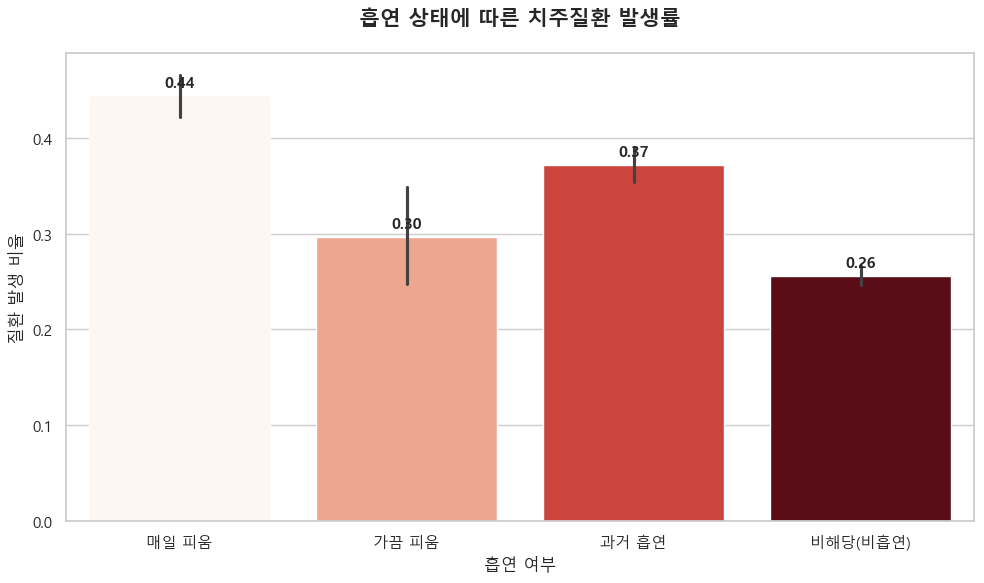

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 및 결측치 제거
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 흡연 여부(BS3_1)와 치주질환(NO_CPI_34) 관계 시각화
plt.figure(figsize=(10, 6))

target = 'NO_CPI_34'
col = 'BS3_1'

# 그래프 생성 (색상은 'Reds'를 사용하여 위험도 강조)
ax = sns.barplot(x=col, y=target, data=df, palette='Reds', hue=col, legend=False)

# x축 라벨을 숫자가 아닌 의미 있는 텍스트로 변경
# (1: 매일, 2: 가끔, 3: 과거 흡연, 4: 비해당/비흡연)
labels = ['매일 피움', '가끔 피움', '과거 흡연', '비해당(비흡연)']
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

# 제목 및 라벨 설정
plt.title('흡연 상태에 따른 치주질환 발생률', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('질환 발생 비율')
plt.xlabel('흡연 여부')

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

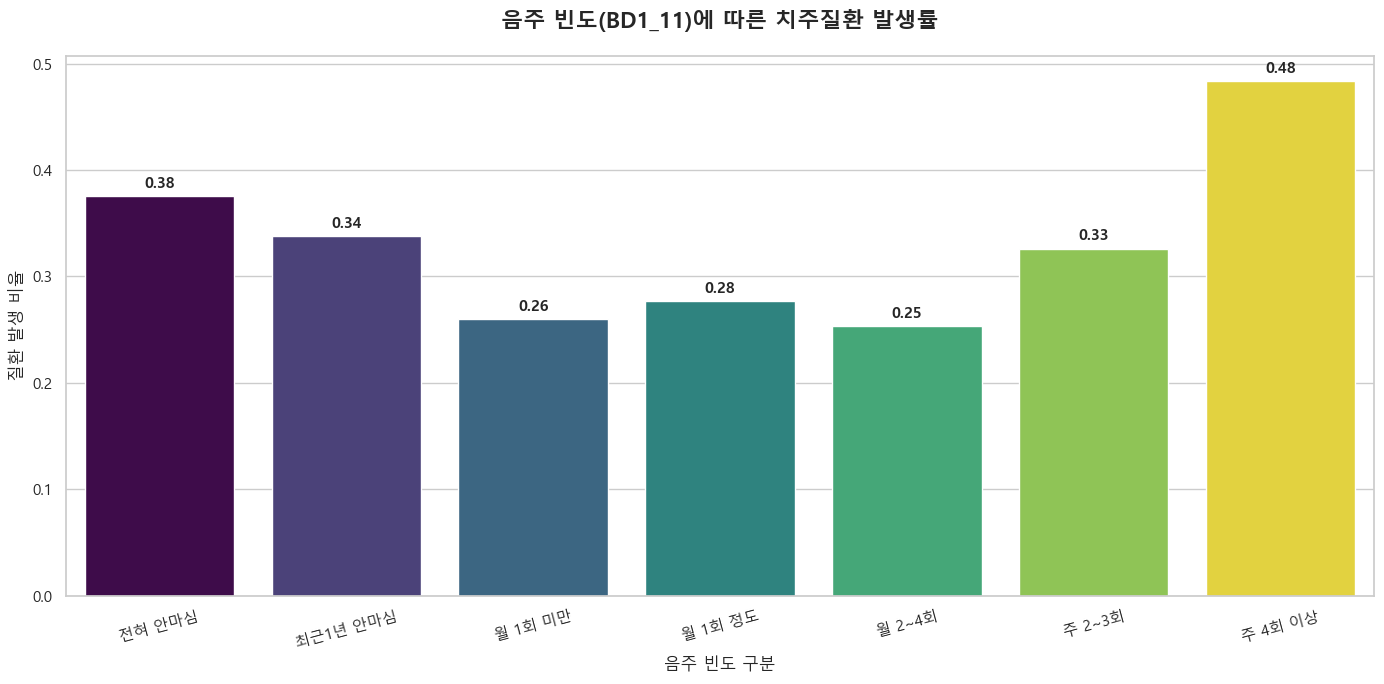

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 시각화 설정
plt.figure(figsize=(14, 7))
target = 'NO_CPI_34'
col = 'BD1_11'

# 데이터에 있는 실제 값 확인 (0, 1, 2, 3, 4, 5, 6 순서 보장)
order = sorted(df[col].unique())

# 그래프 생성
ax = sns.barplot(x=col, y=target, data=df, order=order, palette='viridis', hue=col, legend=False, errorbar=None)

# 4. x축 라벨 설정 (메모장 가이드 0~6 반영)
# 0: 전혀 마신적 없음, 1: 최근 1년간 안마심, 2: 월1회 미만, 3: 월1회 정도, 4: 월2~4회, 5: 주2~3회, 6: 주4회 이상
labels_dict = {
    0: '전혀 안마심',
    1: '최근1년 안마심',
    2: '월 1회 미만',
    3: '월 1회 정도',
    4: '월 2~4회',
    5: '주 2~3회',
    6: '주 4회 이상'
}
current_labels = [labels_dict[val] for val in order]

ax.set_xticks(range(len(current_labels)))
ax.set_xticklabels(current_labels, rotation=15)

# 제목 및 라벨
plt.title('음주 빈도(BD1_11)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('질환 발생 비율')
plt.xlabel('음주 빈도 구분')

# 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

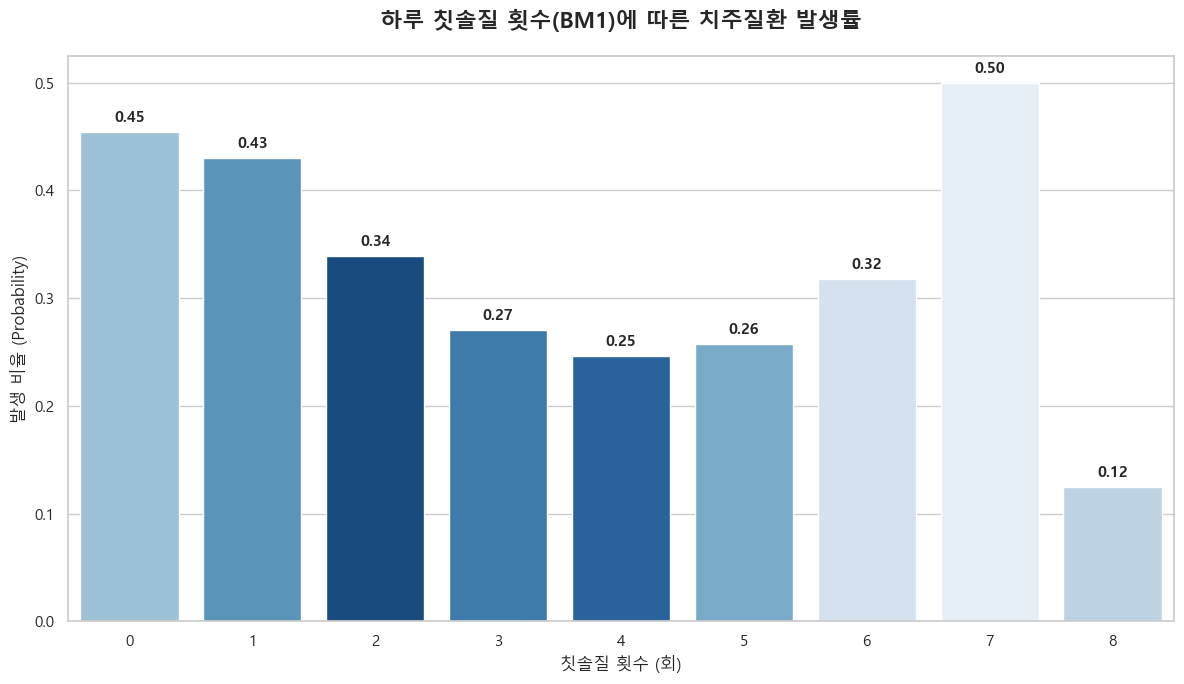

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 및 결측치 전처리
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna(subset=['BM1', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(12, 7))

target = 'NO_CPI_34'
col = 'BM1'

# [포인트] x축 값이 서로 뭉치지 않게 문자열(범주)로 변환
df_plot = df.copy()
df_plot[col] = df_plot[col].astype(int).astype(str)

# 0부터 순서대로 정렬하기 위한 order 생성
order = sorted(df_plot[col].unique(), key=lambda x: int(x))

# 그래프 생성
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='Blues_r', # 횟수가 적을수록 진한 색 (위험 표시)
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('하루 칫솔질 횟수(BM1)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('칫솔질 횟수 (회)')

# 막대 위에 정확한 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

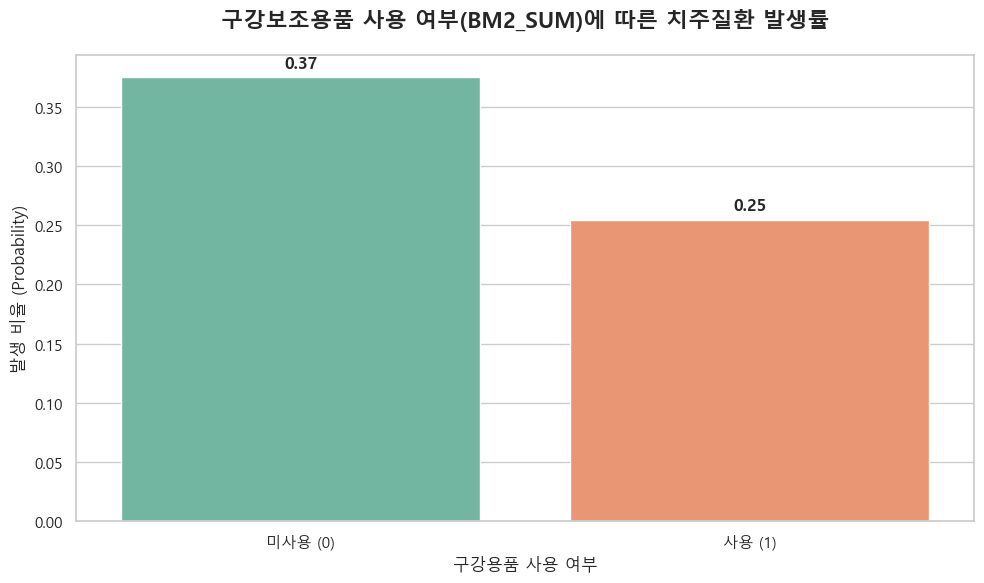

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 결측치 제거 (BM2_SUM과 타겟 변수 기준)
df = df.dropna(subset=['BM2_SUM', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))

target = 'NO_CPI_34'
col = 'BM2_SUM'

# [포인트] 0, 1 값이 뭉치지 않게 문자열로 변환하고 의미 있는 라벨 부여
df_plot = df.copy()
df_plot[col] = df_plot[col].map({0: '미사용 (0)', 1: '사용 (1)'})

# 순서 고정
order = ['미사용 (0)', '사용 (1)']

# 그래프 생성 (관리 여부를 나타내므로 깔끔한 Teal/Green 계열 사용)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='Set2', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('구강보조용품 사용 여부(BM2_SUM)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('구강용품 사용 여부')

# 막대 위에 정확한 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

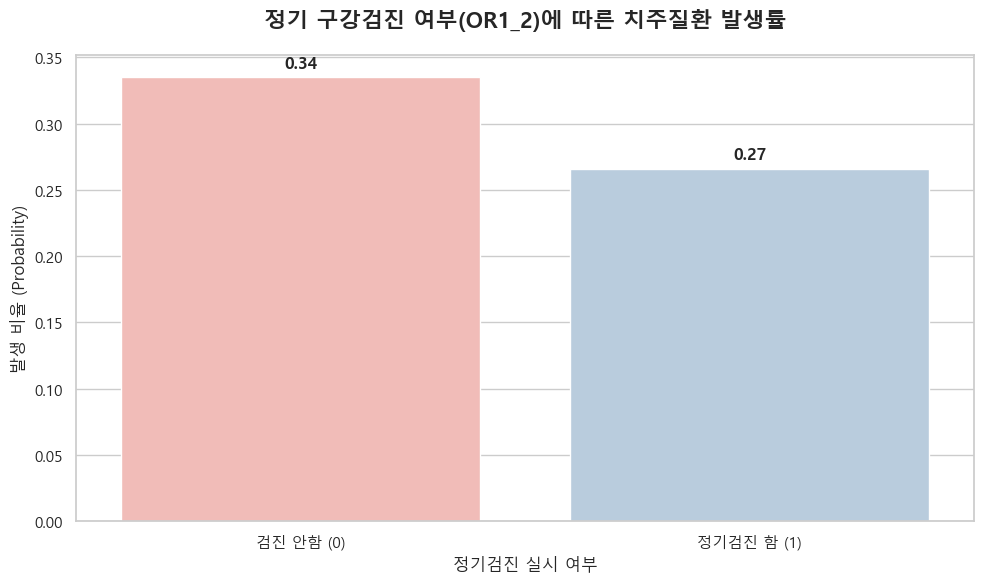

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 결측치 제거 (OR1_2와 타겟 변수 기준)
df = df.dropna(subset=['OR1_2', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))

target = 'NO_CPI_34'
col = 'OR1_2'

# [포인트] 0, 1 값을 문자열 라벨로 변환하여 가독성 향상
df_plot = df.copy()
df_plot[col] = df_plot[col].map({0: '검진 안함 (0)', 1: '정기검진 함 (1)'})

# 출력 순서 고정
order = ['검진 안함 (0)', '정기검진 함 (1)']

# 그래프 생성 (신뢰감을 주는 파란색/오렌지색 조합 사용)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='Pastel1', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('정기 구강검진 여부(OR1_2)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('정기검진 실시 여부')

# 막대 위에 정확한 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

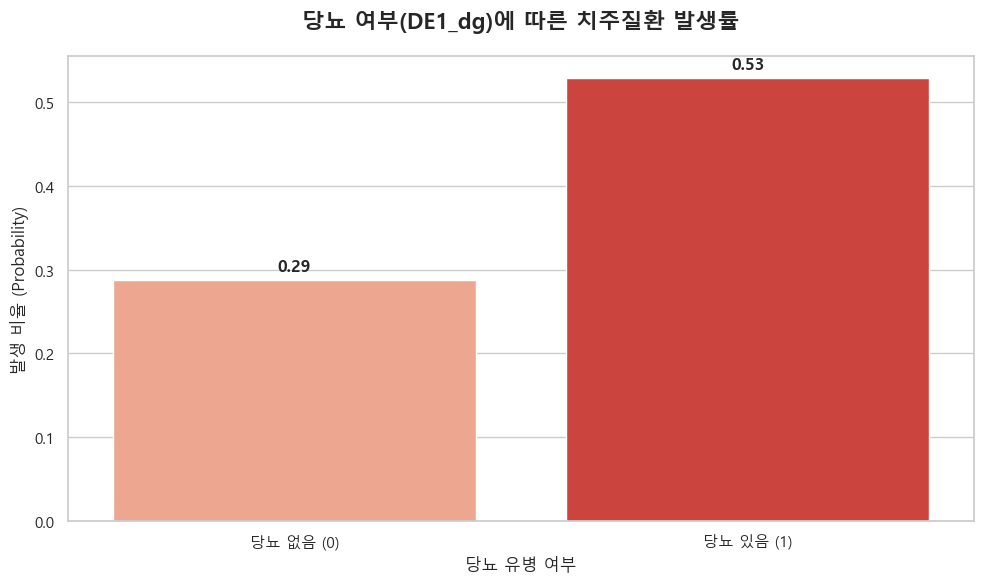

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 결측치 제거
df = df.dropna(subset=['DE1_dg', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))

target = 'NO_CPI_34'
col = 'DE1_dg'

# [포인트] 0, 1 값을 직관적인 문자열 라벨로 변환
df_plot = df.copy()
df_plot[col] = df_plot[col].map({0: '당뇨 없음 (0)', 1: '당뇨 있음 (1)'})

# 출력 순서 고정
order = ['당뇨 없음 (0)', '당뇨 있음 (1)']

# 그래프 생성 (질환의 심각성을 나타내기 위해 'Reds' 계열 활용)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='Reds', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('당뇨 여부(DE1_dg)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('당뇨 유병 여부')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

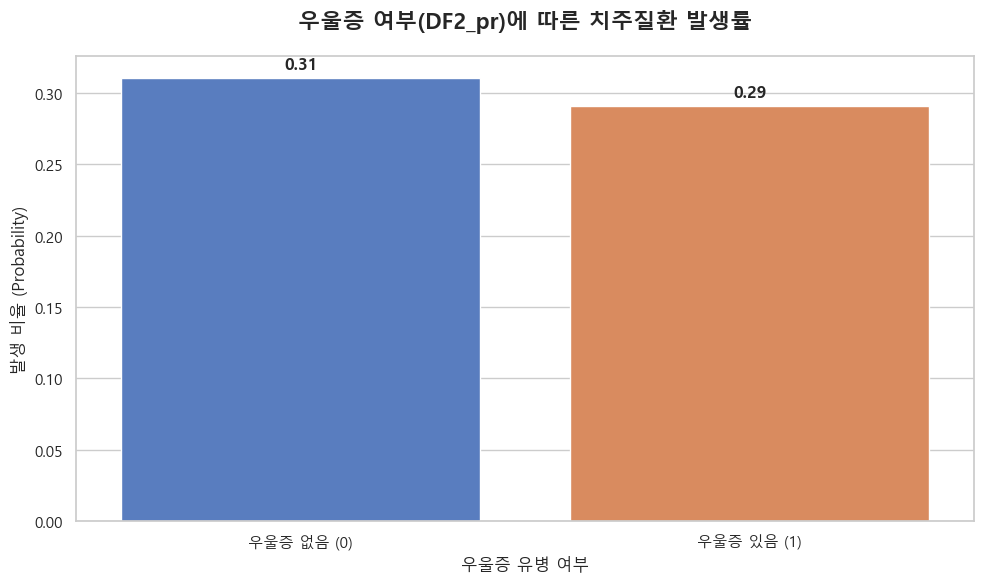

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 결측치 제거
df = df.dropna(subset=['DF2_pr', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))

target = 'NO_CPI_34'
col = 'DF2_pr'

# [포인트] 0, 1 값을 직관적인 문자열 라벨로 변환
df_plot = df.copy()
df_plot[col] = df_plot[col].map({0: '우울증 없음 (0)', 1: '우울증 있음 (1)'})

# 출력 순서 고정
order = ['우울증 없음 (0)', '우울증 있음 (1)']

# 그래프 생성 (차분하지만 대비가 명확한 색상 사용)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='muted', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('우울증 여부(DF2_pr)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('우울증 유병 여부')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

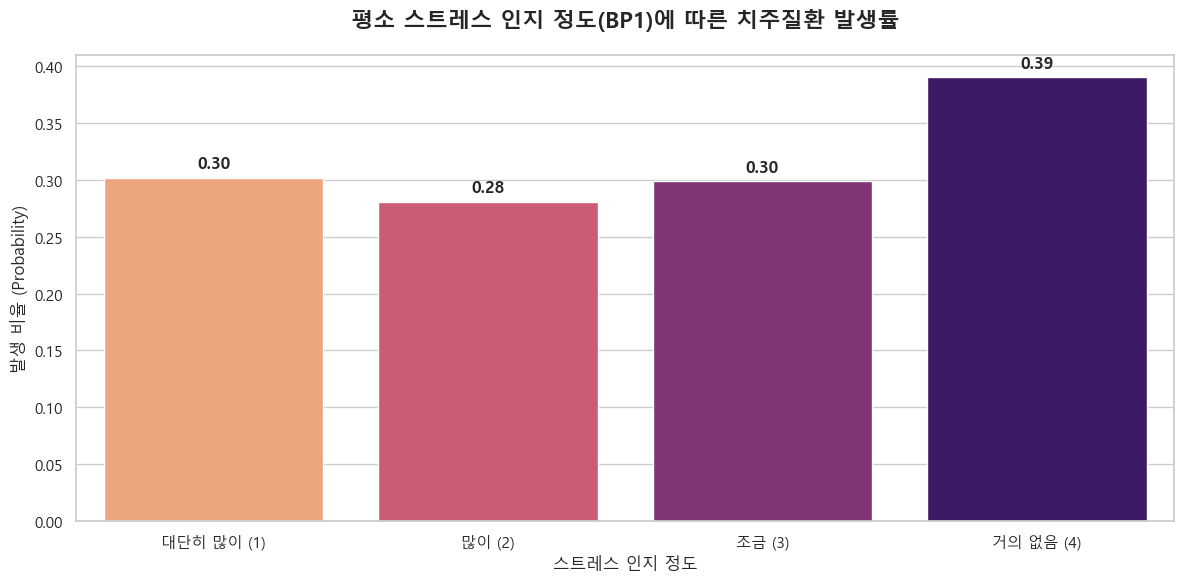

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 결측치 제거
df = df.dropna(subset=['BP1', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(12, 6))

target = 'NO_CPI_34'
col = 'BP1'

# [포인트] 1~4 숫자를 직관적인 문자열 라벨로 변환
# 1. 대단히 많이, 2. 많이, 3. 조금, 4. 거의 느끼지 않음
df_plot = df.copy()
df_plot[col] = df_plot[col].map({
    1: '대단히 많이 (1)',
    2: '많이 (2)',
    3: '조금 (3)',
    4: '거의 없음 (4)'
})

# 출력 순서 고정 (스트레스가 높은 순서대로)
order = ['대단히 많이 (1)', '많이 (2)', '조금 (3)', '거의 없음 (4)']

# 그래프 생성 (스트레스 강도를 시각화하기 위해 파스텔 톤의 순차적 색상 사용)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='magma', # 점진적으로 변하는 색상 팔레트
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('평소 스트레스 인지 정도(BP1)에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('스트레스 인지 정도')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

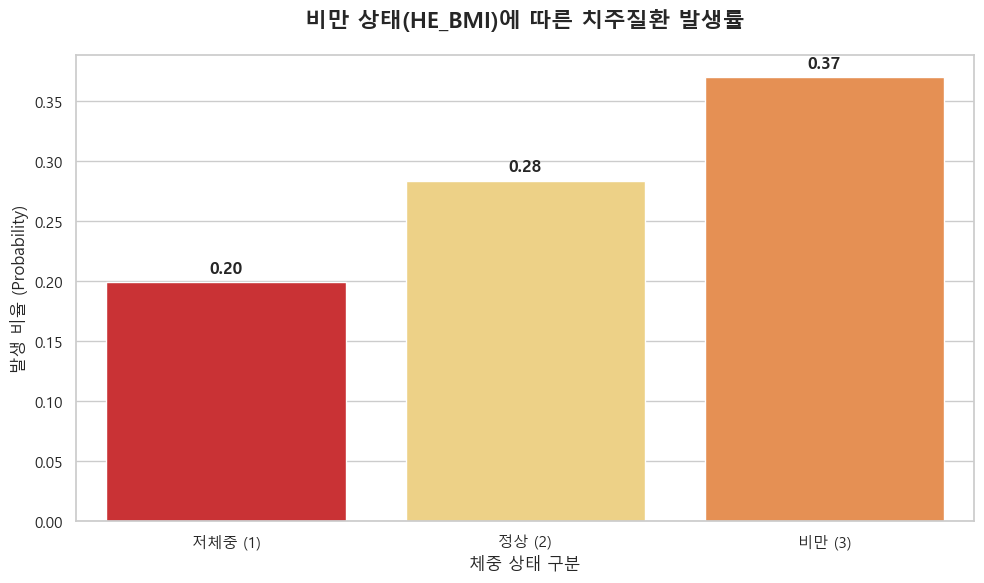

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드
df = pd.read_csv('양치전처리변수늘림.csv')

# --- [오류 해결 포인트] 실제 컬럼명 확인 및 지정 ---
# 데이터에 'HE_obe'가 없을 경우를 대비해 'obe'가 포함된 컬럼을 찾거나 직접 지정
target = 'NO_CPI_34'

# 대소문자 구분 없이 'HE_obe'와 유사한 컬럼 찾기
potential_cols = [c for c in df.columns if 'obe' in c.lower()]
if potential_cols:
    col = potential_cols[0]
    print(f"찾은 컬럼명: {col}")
else:
    # 만약 'HE_obe'가 아예 없다면 코드에서 'HE_BMI' 등을 확인해야 함
    # 우선 에러 방지를 위해 강제 지정 (실제 파일에 있는 이름으로 수정 필요할 수 있음)
    col = 'HE_BMI' 

# 결측치 제거
df = df.dropna(subset=[col, target]).reset_index(drop=True)

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))

# 1: 저체중, 2: 정상, 3: 비만 맵핑
df_plot = df.copy()
df_plot[col] = df_plot[col].map({
    1: '저체중 (1)',
    2: '정상 (2)',
    3: '비만 (3)'
})

# 출력 순서 고정
order = ['저체중 (1)', '정상 (2)', '비만 (3)']

# 그래프 생성
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='YlOrRd', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title(f'비만 상태({col})에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('체중 상태 구분')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height): # 값이 있는 경우만 표시
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

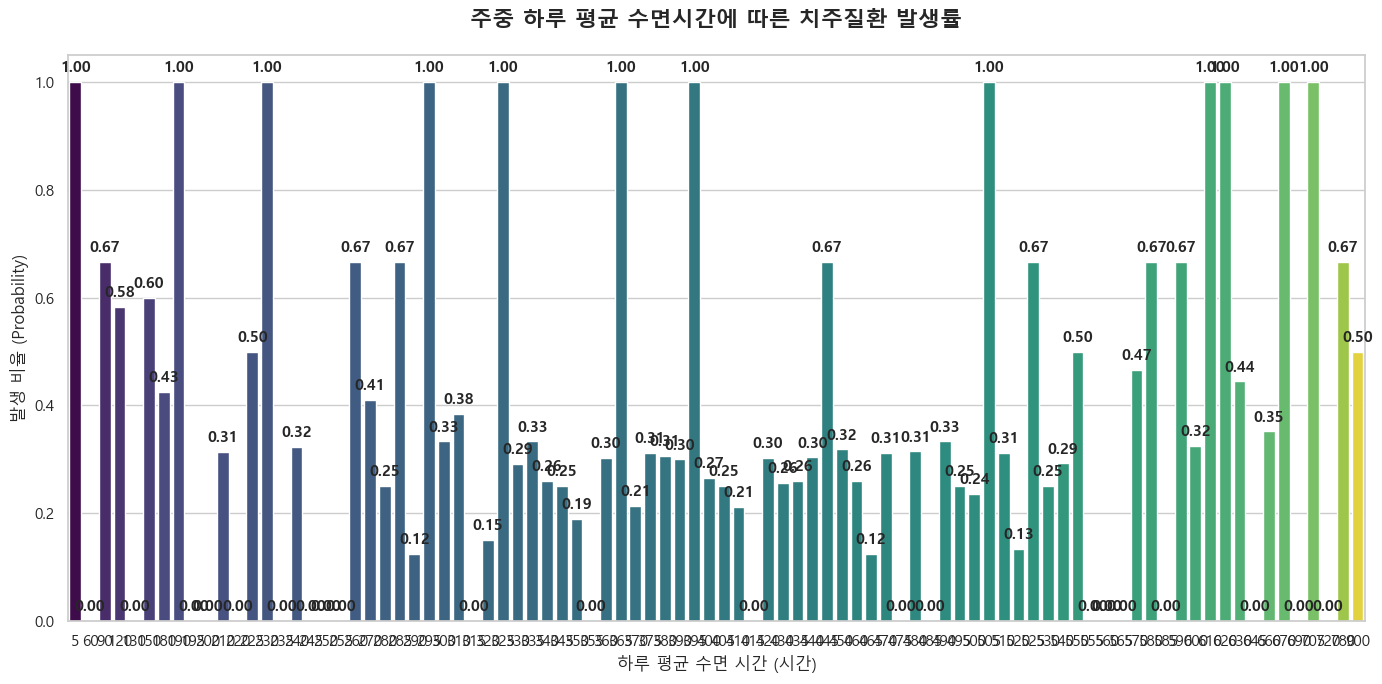

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 (8888: 모름/무응답, 9999: 해당없음 제거)
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df = df.dropna(subset=['Total_slp_wk', 'NO_CPI_34']).reset_index(drop=True)

# 3. 그래프 시각화 준비
plt.figure(figsize=(14, 7))

target = 'NO_CPI_34'
col = 'Total_slp_wk'

# [포인트] 수면시간을 정수형으로 변환하여 x축 라벨이 꼬이지 않게 설정
df_plot = df.copy()
df_plot[col] = df_plot[col].astype(int)

# 0~12시간 등 실제 데이터가 있는 범위 내에서 정렬
order = sorted(df_plot[col].unique())

# 그래프 생성 (수면의 질을 나타내기 위해 차분한 'viridis' 팔레트 사용)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df_plot, 
    order=order, 
    palette='viridis', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('주중 하루 평균 수면시간에 따른 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('하루 평균 수면 시간 (시간)')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

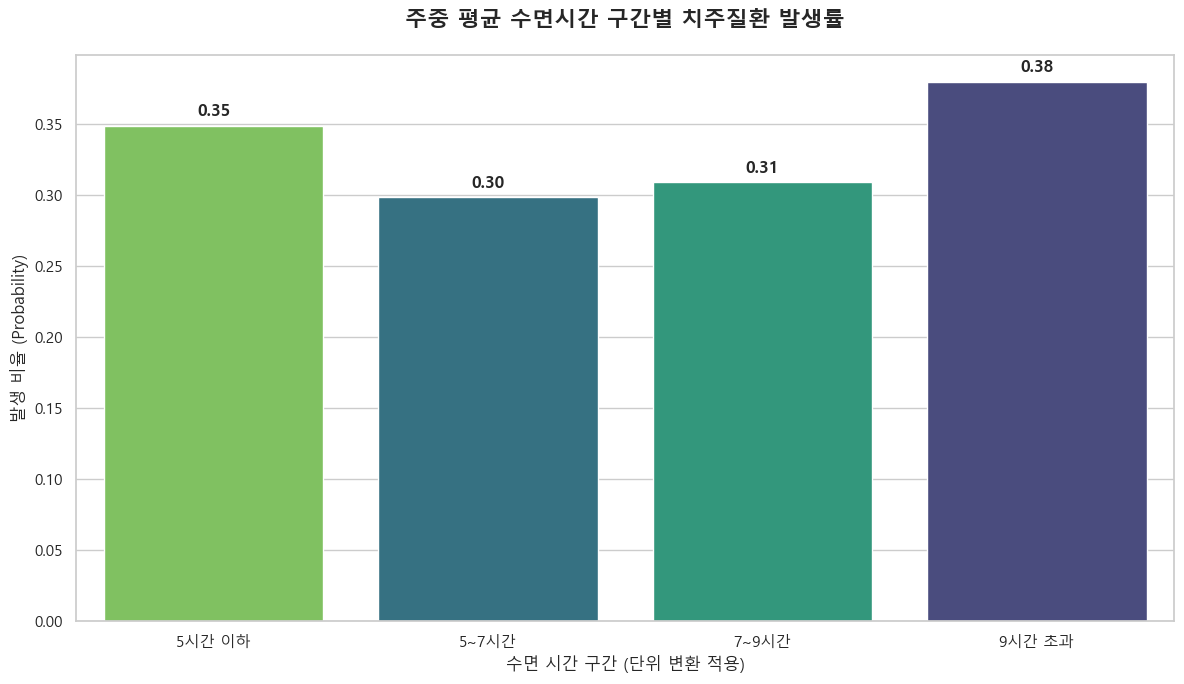

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 수면시간 이상치 처리 (8888, 9999 제거)
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df = df.dropna(subset=['Total_slp_wk', 'NO_CPI_34']).reset_index(drop=True)

# --- [핵심 수정] 분(Min) 단위를 시간(Hour) 단위로 변환 ---
# 데이터가 분 단위(예: 420분)라면 60으로 나누어 시간(7시간)으로 바꿉니다.
df['Total_slp_wk_hour'] = df['Total_slp_wk'] / 60

# 3. 수면시간 구간 나누기 (Binning)
def get_sleep_group(time):
    if time <= 5:
        return '5시간 이하'
    elif 5 < time <= 7:
        return '5~7시간'
    elif 7 < time <= 9:
        return '7~9시간'
    else:
        return '9시간 초과'

# 변환된 시간 컬럼을 기준으로 그룹 생성
df['Sleep_Group'] = df['Total_slp_wk_hour'].apply(get_sleep_group)

# 4. 그래프 시각화
plt.figure(figsize=(12, 7))

target = 'NO_CPI_34'
col = 'Sleep_Group'

# x축 출력 순서 강제 지정
order = ['5시간 이하', '5~7시간', '7~9시간', '9시간 초과']

# 그래프 생성
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df, 
    order=order, 
    palette='viridis', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('주중 평균 수면시간 구간별 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('수면 시간 구간 (단위 변환 적용)')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

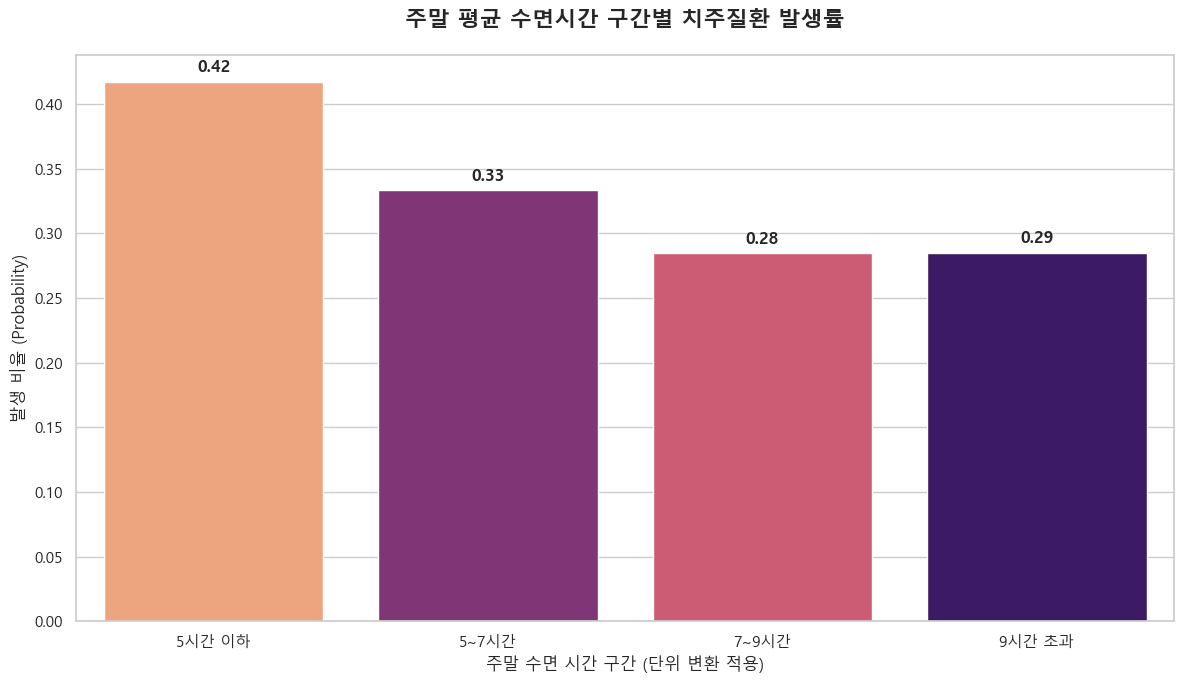

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 주말 수면시간 이상치 처리 (8888, 9999 제거)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna(subset=['Total_slp_wd', 'NO_CPI_34']).reset_index(drop=True)

# --- [핵심] 분(Min) 단위를 시간(Hour) 단위로 변환 ---
df['Total_slp_wd_hour'] = df['Total_slp_wd'] / 60

# 3. 수면시간 구간 나누기 (Binning)
def get_sleep_group(time):
    if time <= 5:
        return '5시간 이하'
    elif 5 < time <= 7:
        return '5~7시간'
    elif 7 < time <= 9:
        return '7~9시간'
    else:
        return '9시간 초과'

# 주말 시간 컬럼을 기준으로 그룹 생성
df['Sleep_Group_WD'] = df['Total_slp_wd_hour'].apply(get_sleep_group)

# 4. 그래프 시각화
plt.figure(figsize=(12, 7))

target = 'NO_CPI_34'
col = 'Sleep_Group_WD'

# x축 출력 순서 강제 지정
order = ['5시간 이하', '5~7시간', '7~9시간', '9시간 초과']

# 그래프 생성 (주말 느낌을 주기 위해 색상을 'magma'로 변경해 보았습니다)
ax = sns.barplot(
    x=col, 
    y=target, 
    data=df, 
    order=order, 
    palette='magma', 
    hue=col, 
    legend=False,
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('주말 평균 수면시간 구간별 치주질환 발생률', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('발생 비율 (Probability)')
plt.xlabel('주말 수면 시간 구간 (단위 변환 적용)')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
# 그래프 2개 합치기

# 음주 흡연 합치기

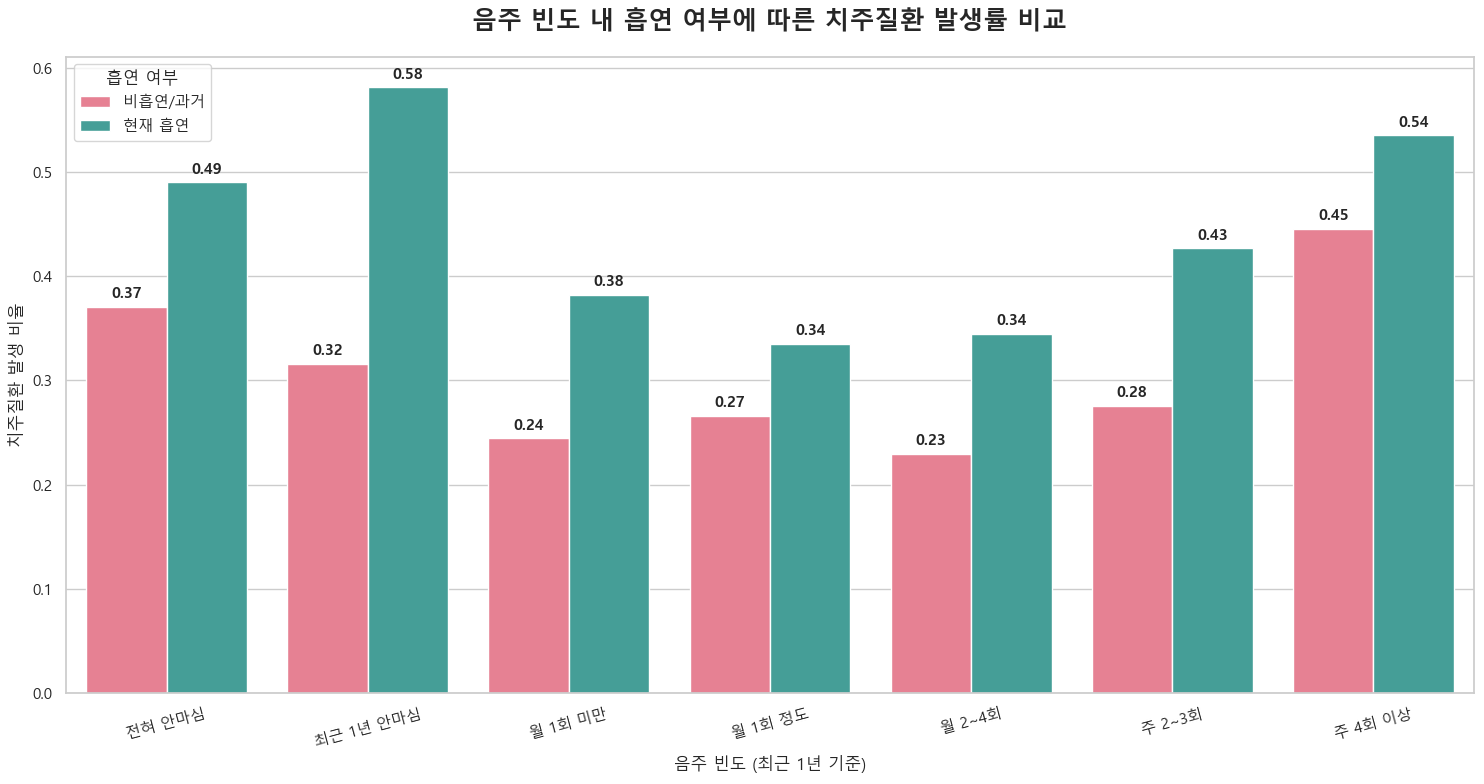

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 결측치 제거
df_sub = df[['BS3_1', 'BD1_11', 'NO_CPI_34']].dropna()

# 3. 그룹화 레이블 설정
# 흡연: 비흡연/과거 vs 현재 흡연
df_sub['흡연상태'] = df_sub['BS3_1'].apply(lambda x: '현재 흡연' if x in [1, 2] else '비흡연/과거')

# 음주: 7단계 레이블
drink_labels = {
    0: '전혀 안마심', 1: '최근 1년 안마심', 2: '월 1회 미만', 
    3: '월 1회 정도', 4: '월 2~4회', 5: '주 2~3회', 6: '주 4회 이상'
}
df_sub['음주빈도'] = df_sub['BD1_11'].map(drink_labels)
drink_order = list(drink_labels.values())

# 4. 시각화
plt.figure(figsize=(15, 8))

target = 'NO_CPI_34'

# 그룹화 막대그래프 생성 (x축: 음주빈도, hue: 흡연상태)
ax = sns.barplot(
    x='음주빈도', 
    y=target, 
    hue='흡연상태', 
    data=df_sub, 
    order=drink_order,
    palette='husl', # 색상 대비가 명확한 팔레트
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('음주 빈도 내 흡연 여부에 따른 치주질환 발생률 비교', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('치주질환 발생 비율', fontsize=12)
plt.xlabel('음주 빈도 (최근 1년 기준)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='흡연 여부', loc='upper left')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [35]:
# 당뇨 정기검진 합치

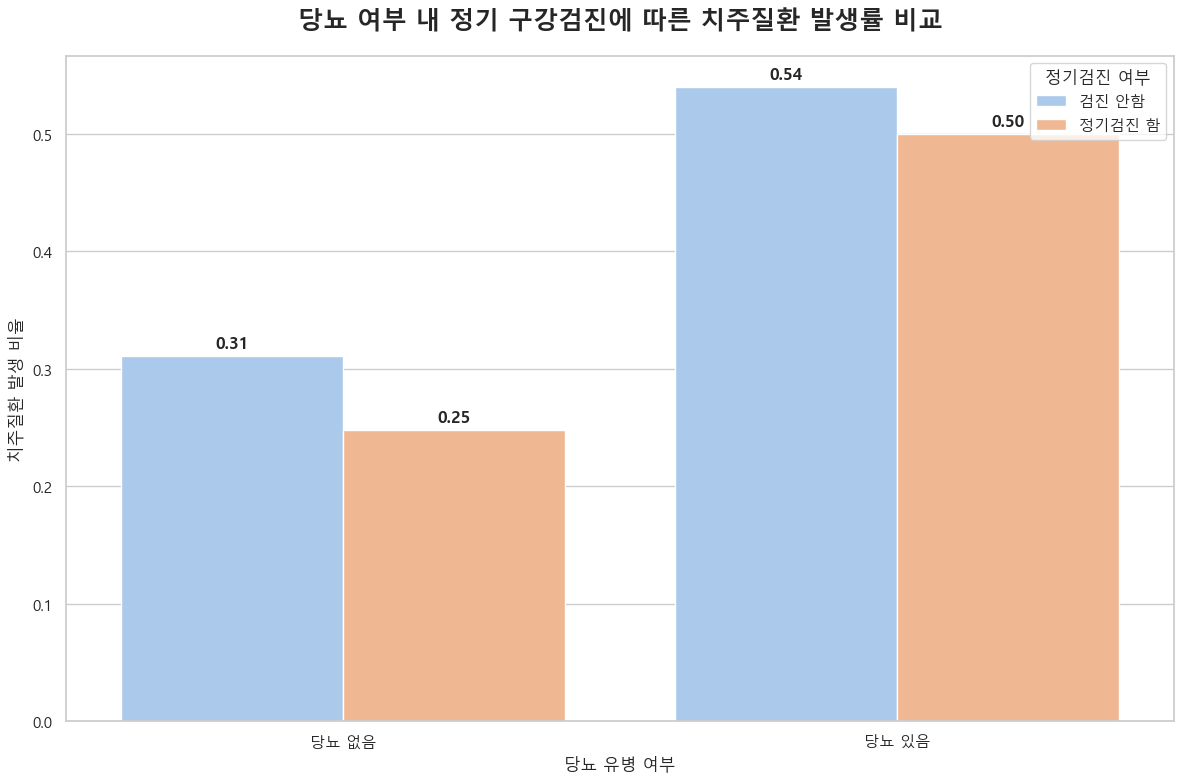

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 분석에 필요한 변수들만 추출 및 결측치 제거
# DE1_dg: 당뇨여부, OR1_2: 정기검진여부, NO_CPI_34: 치주질환여부(타겟)
df_sub = df[['DE1_dg', 'OR1_2', 'NO_CPI_34']].dropna()

# 3. 그룹화 레이블 설정 (가독성을 위해 0, 1을 문자로 변환)
df_sub['당뇨상태'] = df_sub['DE1_dg'].map({0: '당뇨 없음', 1: '당뇨 있음'})
df_sub['검진여부'] = df_sub['OR1_2'].map({0: '검진 안함', 1: '정기검진 함'})

# 4. 시각화
plt.figure(figsize=(12, 8))

target = 'NO_CPI_34'

# 그룹화 막대그래프 생성 (x축: 당뇨상태, hue: 검진여부)
ax = sns.barplot(
    x='당뇨상태', 
    y=target, 
    hue='검진여부', 
    data=df_sub, 
    palette='pastel', # 부드러운 파스텔 톤 색상
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('당뇨 여부 내 정기 구강검진에 따른 치주질환 발생률 비교', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('치주질환 발생 비율', fontsize=12)
plt.xlabel('당뇨 유병 여부', fontsize=12)
plt.legend(title='정기검진 여부', loc='upper right')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# 칫솔질, 구강용품

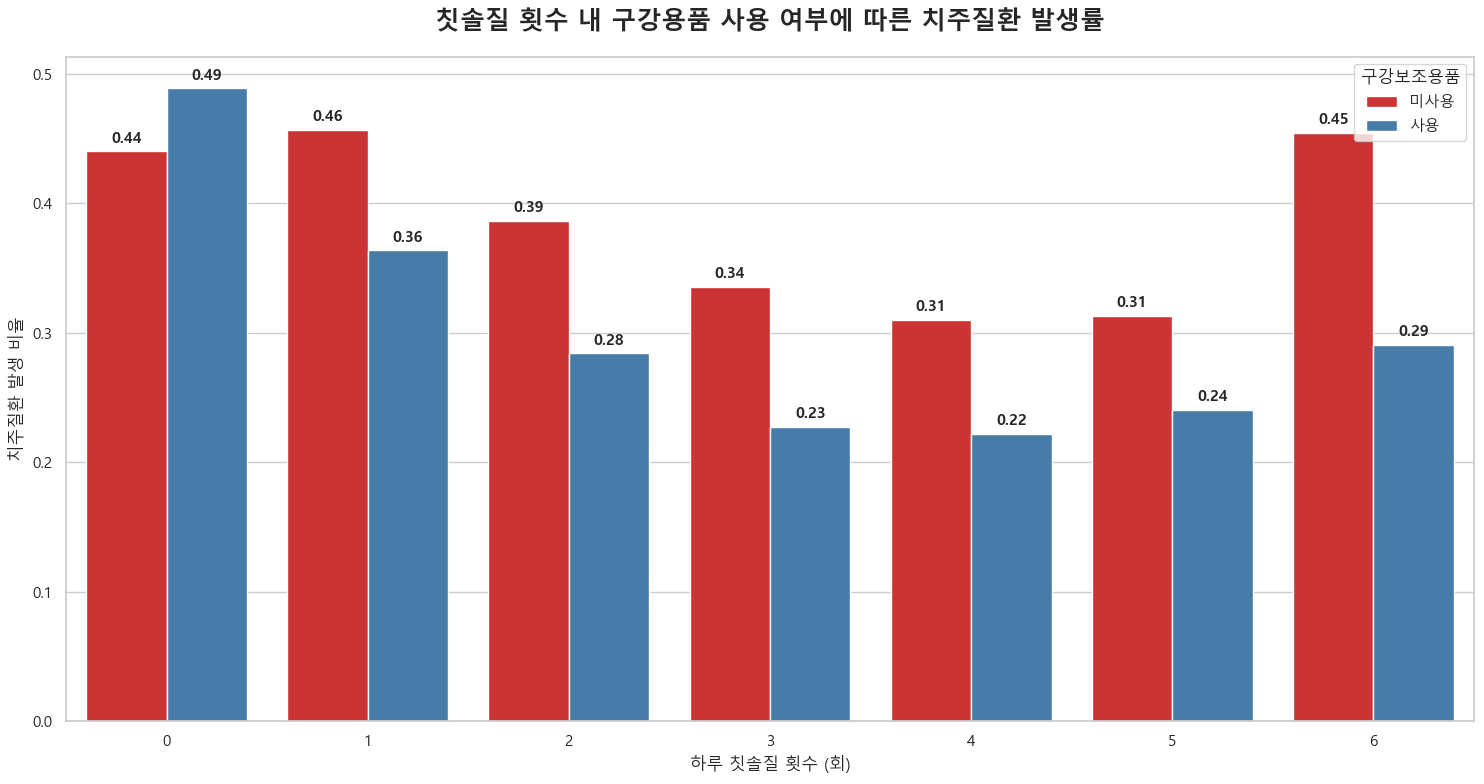

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')

# 분석에 필요한 변수 추출 및 결측치 제거
# BM1: 칫솔질 횟수, BM2_SUM: 구강용품 사용여부, NO_CPI_34: 치주질환여부
df_sub = df[['BM1', 'BM2_SUM', 'NO_CPI_34']].dropna()

# 3. 그룹화 레이블 및 데이터 정리
# 칫솔질 횟수를 정수형으로 변환 (x축 정렬을 위해)
df_sub['칫솔질_횟수'] = df_sub['BM1'].astype(int)

# 구강용품 사용 여부 레이블 맵핑
df_sub['구강용품_사용'] = df_sub['BM2_SUM'].map({0: '미사용', 1: '사용'})

# x축에 표시할 칫솔질 횟수 범위 설정 (보통 0~5회 정도가 유의미함)
brush_order = sorted(df_sub[df_sub['칫솔질_횟수'] <= 6]['칫솔질_횟수'].unique())

# 4. 시각화
plt.figure(figsize=(15, 8))

target = 'NO_CPI_34'

# 그룹화 막대그래프 생성 (x축: 칫솔질_횟수, hue: 구강용품_사용)
ax = sns.barplot(
    x='칫솔질_횟수', 
    y=target, 
    hue='구강용품_사용', 
    data=df_sub, 
    order=brush_order,
    palette='Set1', # 미사용/사용 대비가 명확한 색상
    errorbar=None
)

# 제목 및 라벨 설정
plt.title('칫솔질 횟수 내 구강용품 사용 여부에 따른 치주질환 발생률', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('치주질환 발생 비율', fontsize=12)
plt.xlabel('하루 칫솔질 횟수 (회)', fontsize=12)
plt.legend(title='구강보조용품', loc='upper right')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()